In [1]:
# ── Instalação automática de dependências ─────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")
import subprocess, sys

def instalar(pacote):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pacote, "-q"])

for pkg in ["duckdb", "pandas", "matplotlib", "seaborn", "plotly", "kaleido", "squarify"]:
    try:
        __import__(pkg.split("[")[0])
    except ImportError:
        print(f"Instalando {pkg}...")
        instalar(pkg)

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import squarify
import numpy as np

In [4]:
# Paleta do projeto
PALETA = {
    "azul_profundo": "#1A3C5E",
    "azul_medio":    "#2E86AB",
    "verde_teal":    "#17A589",
    "vermelho":      "#E74C3C",
    "ambar":         "#F39C12",
    "roxo":          "#6C3483",
    "cinza_escuro":  "#2C3E50",
    "cinza_claro":   "#BDC3C7",
}
 
COR_VERTENTE = {
    "populacao": PALETA["azul_medio"],
    "clinica":   PALETA["vermelho"],
    "economica": PALETA["cinza_escuro"],
}
 
plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          False,
    "grid.alpha":         0.3,
    "figure.dpi":         150,
    "savefig.dpi":        150,
    "savefig.bbox":       "tight",
    "savefig.facecolor":  "white",
})

In [5]:
# ── Carrega CSV e configura DuckDB ────────────────────────────────────────────
import duckdb
import pandas as pd

CSV_PATH = r"C:\Users\Jonat\Downloads\PNAD_GOLD.csv"

print(f"Carregando {CSV_PATH} ...")
_df = pd.read_csv(CSV_PATH)
print(f"  {len(_df):,} linhas × {len(_df.columns)} colunas carregadas")

# Registra o DataFrame com o mesmo nome de tabela usado nas queries
con = duckdb.connect()
con.register(TABELA, _df)

def q(sql):
    """Executa SQL via DuckDB sobre o CSV carregado."""
    print("  → Executando...")
    df = con.execute(sql).df()
    print(f"     {len(df)} linhas retornadas")
    return df

print("✅ Pronto — DuckDB conectado ao CSV")

Carregando C:\Users\Jonat\Downloads\PNAD_GOLD.csv ...
  1,149,197 linhas × 42 colunas carregadas
✅ Pronto — DuckDB conectado ao CSV


  → Executando...
     2 linhas retornadas


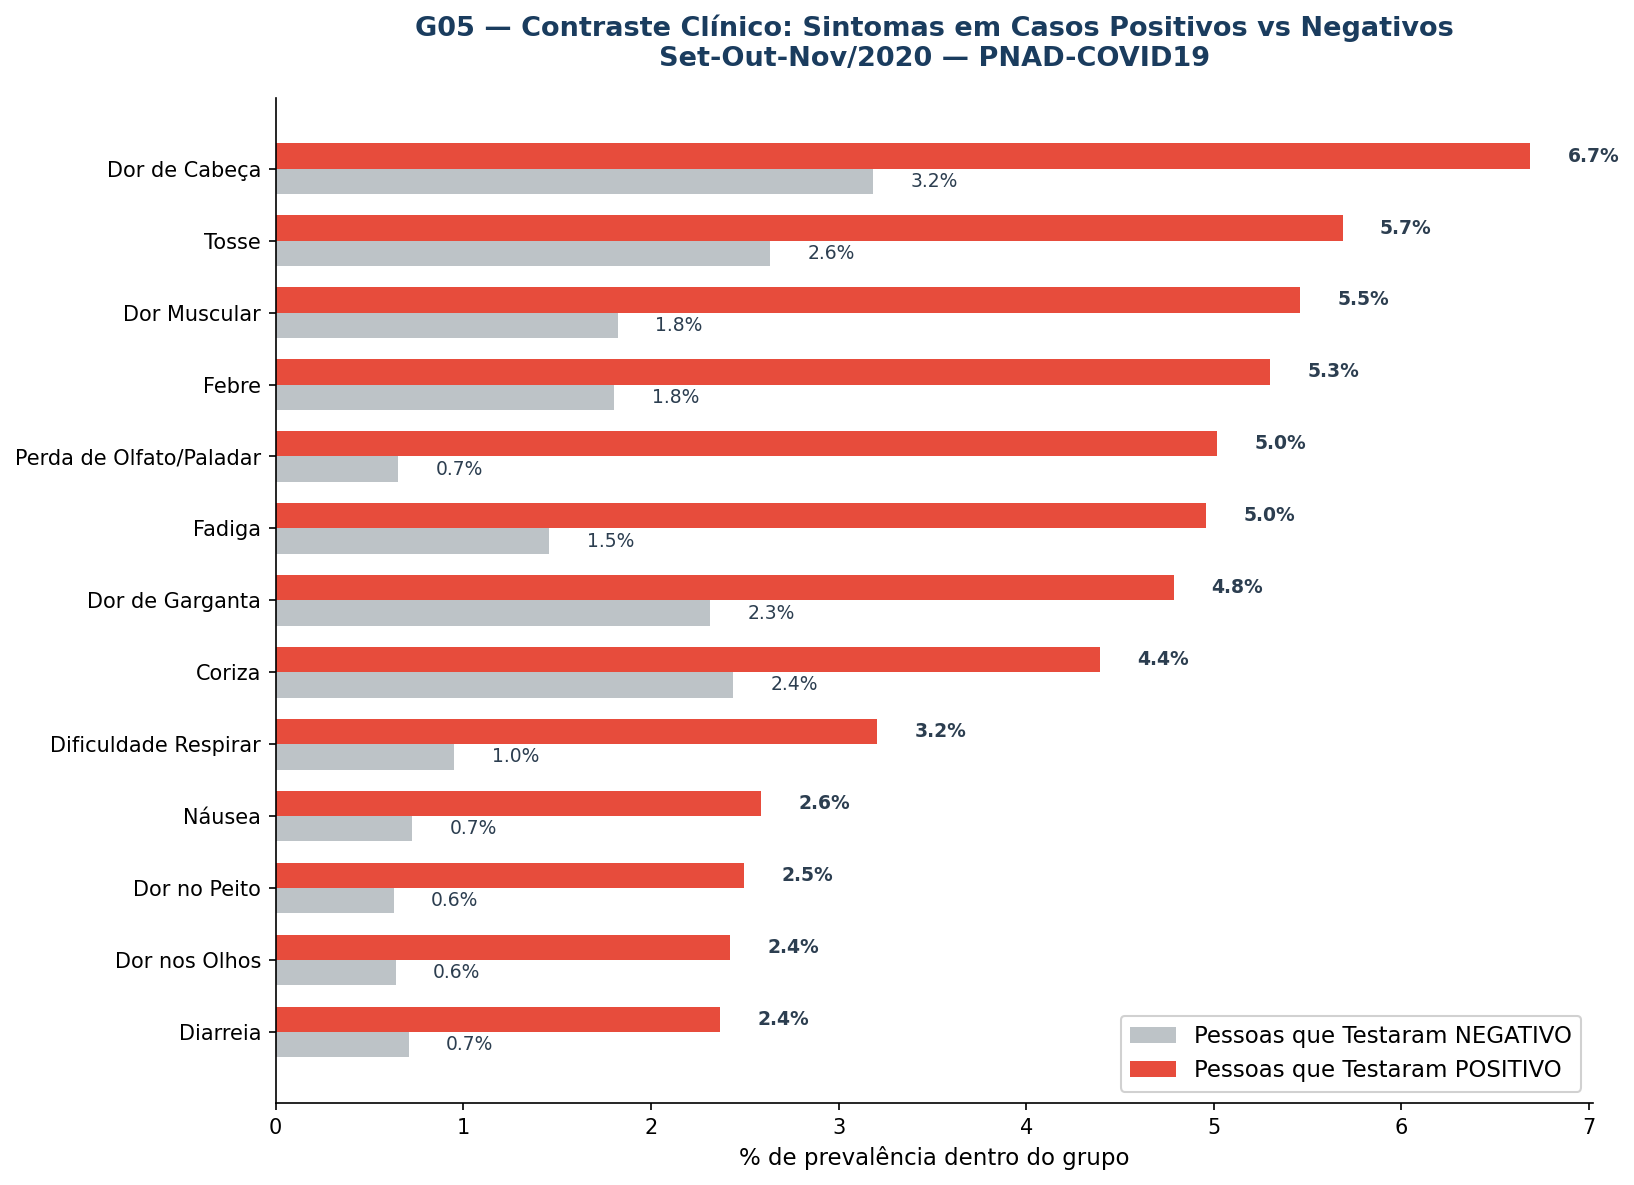

✅ G05 atualizado com comparação Positivo vs Negativo


In [52]:

# ── G05. Prevalência de Sintomas: Confirmados (Positivos) vs Negativos ───────

df_g05 = q(f"""
    SELECT
        CASE 
            WHEN resultado_teste_swab = 'Positivo'
              OR resultado_teste_sangue_dedo = 'Positivo'
              OR resultado_teste_sangue_veia = 'Positivo' THEN 'Confirmado'
            WHEN resultado_teste_swab = 'Negativo'
              OR resultado_teste_sangue_dedo = 'Negativo'
              OR resultado_teste_sangue_veia = 'Negativo' THEN 'Negativo'
            ELSE 'Não Testado' 
        END AS status_teste,
        COUNT(*) AS total,
        SUM(CASE WHEN sintoma_febre = 'Sim' THEN 1 ELSE 0 END) AS febre,
        SUM(CASE WHEN sintoma_tosse = 'Sim' THEN 1 ELSE 0 END) AS tosse,
        SUM(CASE WHEN sintoma_dor_garganta = 'Sim' THEN 1 ELSE 0 END) AS dor_garganta,
        SUM(CASE WHEN sintoma_dificuldade_respirar = 'Sim' THEN 1 ELSE 0 END) AS dificuldade_respirar,
        SUM(CASE WHEN sintoma_dor_cabeca = 'Sim' THEN 1 ELSE 0 END) AS dor_cabeca,
        SUM(CASE WHEN sintoma_dor_peito = 'Sim' THEN 1 ELSE 0 END) AS dor_peito,
        SUM(CASE WHEN sintoma_nausea = 'Sim' THEN 1 ELSE 0 END) AS nausea,
        SUM(CASE WHEN sintoma_coriza = 'Sim' THEN 1 ELSE 0 END) AS coriza,
        SUM(CASE WHEN sintoma_fadiga = 'Sim' THEN 1 ELSE 0 END) AS fadiga,
        SUM(CASE WHEN sintoma_dor_olhos = 'Sim' THEN 1 ELSE 0 END) AS dor_olhos,
        SUM(CASE WHEN sintoma_perda_olfato_paladar = 'Sim' THEN 1 ELSE 0 END) AS perda_olfato,
        SUM(CASE WHEN sintoma_dor_muscular = 'Sim' THEN 1 ELSE 0 END) AS dor_muscular,
        SUM(CASE WHEN sintoma_diarreia = 'Sim' THEN 1 ELSE 0 END) AS diarreia
    FROM {TABELA}
    WHERE status_teste IN ('Confirmado', 'Negativo')
    GROUP BY 1
""")

# Prepara os dados para o gráfico
sintomas_list = df_g05.columns[2:]

# % para Confirmados
df_pos = df_g05[df_g05['status_teste'] == 'Confirmado'].iloc[0]
pct_pos = (df_pos[sintomas_list] / df_pos['total']) * 100

# % para Negativos
df_neg = df_g05[df_g05['status_teste'] == 'Negativo'].iloc[0]
pct_neg = (df_neg[sintomas_list] / df_neg['total']) * 100

# Monta DataFrame final
sintomas = pd.DataFrame({
    'sintoma': sintomas_list,
    'pct_negativo': pct_neg.values.astype(float),
    'pct_confirmado': pct_pos.values.astype(float)
})

# Ordenação baseada na diferença (onde a Covid mais se destaca)
sintomas['diff'] = sintomas['pct_confirmado'] - sintomas['pct_negativo']
sintomas = sintomas.sort_values('pct_confirmado', ascending=True)

# Nomes legíveis
labels = {
    'febre': 'Febre', 'tosse': 'Tosse', 'dor_garganta': 'Dor de Garganta',
    'dificuldade_respirar':'Dificuldade Respirar', 'dor_cabeca': 'Dor de Cabeça',
    'dor_peito': 'Dor no Peito', 'nausea': 'Náusea', 'coriza': 'Coriza',
    'fadiga': 'Fadiga', 'dor_olhos': 'Dor nos Olhos', 'perda_olfato': 'Perda de Olfato/Paladar',
    'dor_muscular': 'Dor Muscular', 'diarreia': 'Diarreia'
}
sintomas['label'] = sintomas['sintoma'].map(labels)

fig, ax = plt.subplots(figsize=(11, 8))
y = np.arange(len(sintomas))
width = 0.35

# Plota Negativos
bars_neg = ax.barh(y - width/2, sintomas['pct_negativo'], width, 
                     label='Pessoas que Testaram NEGATIVO', color=PALETA['cinza_claro'])

# Plota Confirmados
bars_pos = ax.barh(y + width/2, sintomas['pct_confirmado'], width, 
                    label='Pessoas que Testaram POSITIVO', color=PALETA['vermelho'])

# Rótulos nas barras de negativos
for bar, val in zip(bars_neg, sintomas['pct_negativo']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color=PALETA['cinza_escuro'])

# Rótulos nas barras de positivos
for bar, val in zip(bars_pos, sintomas['pct_confirmado']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color=PALETA['cinza_escuro'], fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(sintomas['label'], fontsize=10)
ax.set_xlabel('% de prevalência dentro do grupo', fontsize=11)
ax.set_title('G05 — Contraste Clínico: Sintomas em Casos Positivos vs Negativos\nSet-Out-Nov/2020 — PNAD-COVID19',
             fontsize=13, fontweight='bold', color=PALETA['azul_profundo'], pad=15)

ax.legend(loc='lower right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G05_prevalencia_sintomas.png')
plt.show()
print("✅ G05 atualizado com comparação Positivo vs Negativo")


In [16]:
[c for c in _df.columns if 'plano' in c.lower()]

[]

  → Executando...
     1 linhas retornadas


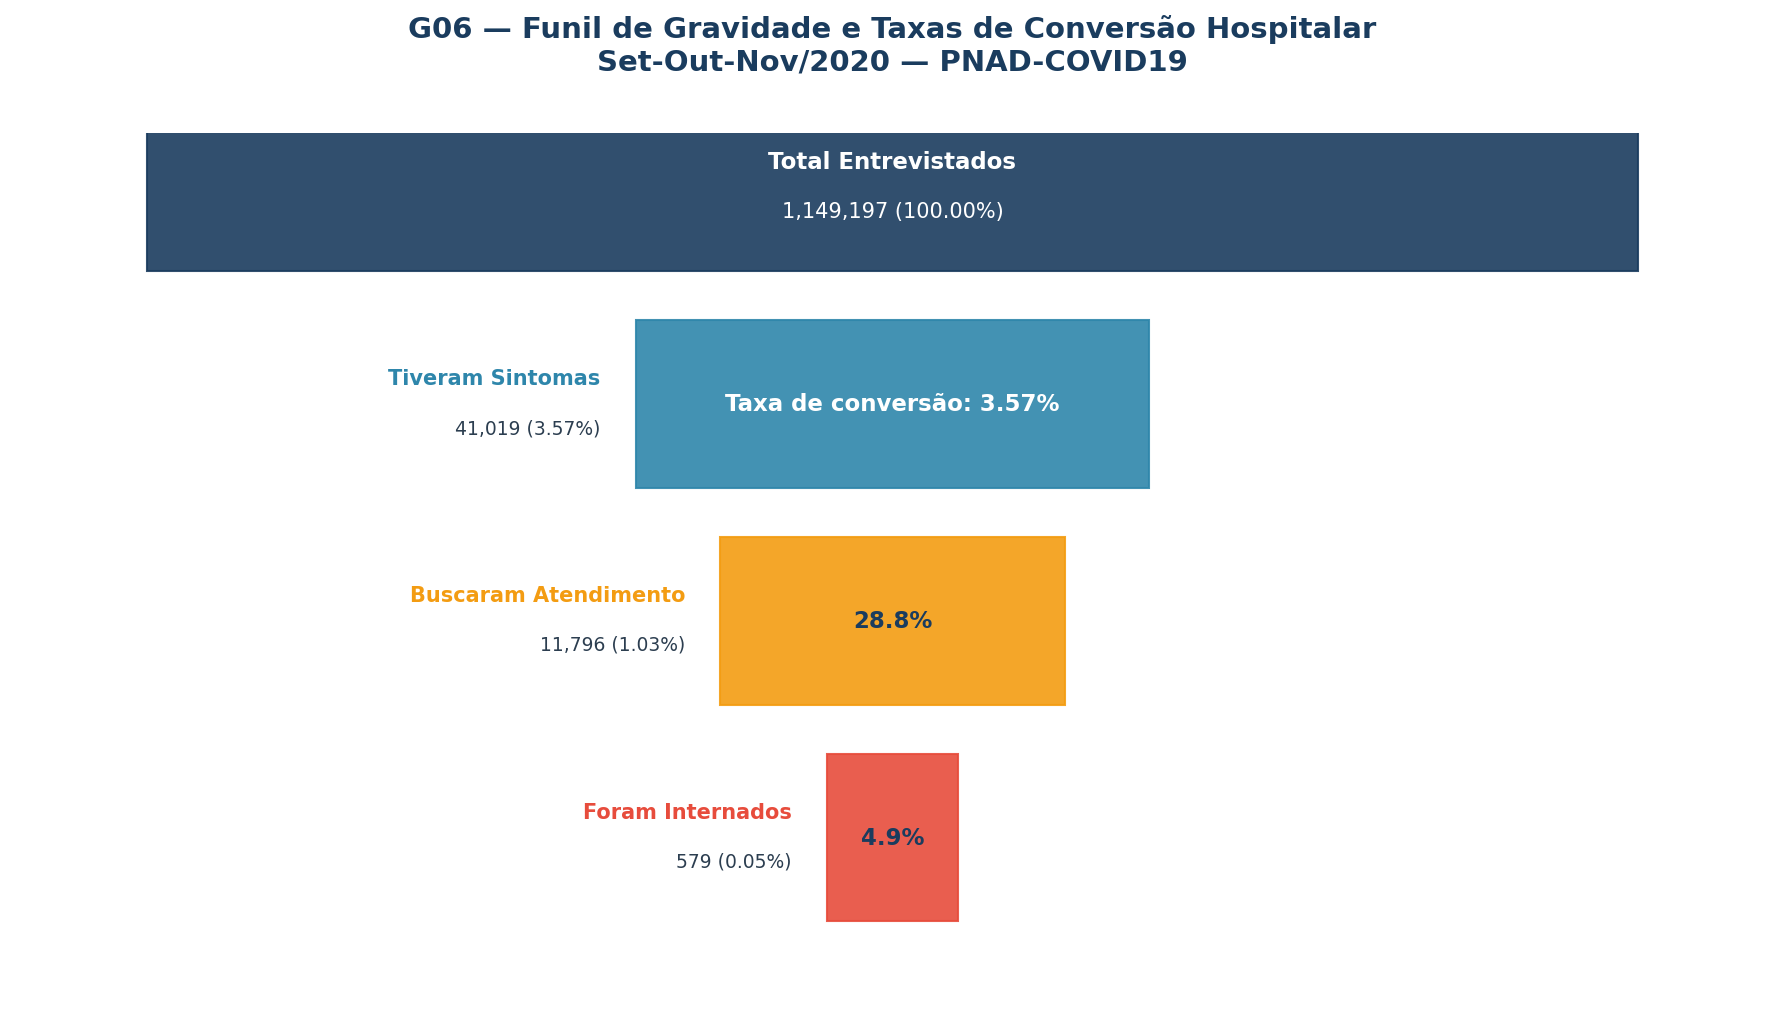

✅ G06 atualizado com o padrão de conversão interna solicitado.


In [19]:
# ── G06. Funil de Gravidade: Conversão Interna Estruturada ────────────────────

df_g06 = q(f"""
    SELECT
        COUNT(*) AS total_entrevistados,
        SUM(CASE WHEN (sintoma_febre = 'Sim' OR sintoma_tosse = 'Sim' 
                   OR sintoma_dor_garganta = 'Sim' OR sintoma_dificuldade_respirar = 'Sim'
                   OR sintoma_dor_cabeca = 'Sim' OR sintoma_coriza = 'Sim' 
                   OR sintoma_fadiga = 'Sim' OR sintoma_perda_olfato_paladar = 'Sim') 
            THEN 1 ELSE 0 END) AS teve_sintoma,
        SUM(CASE WHEN buscou_atendimento = 'Sim' THEN 1 ELSE 0 END) AS buscou_atendimento,
        SUM(CASE WHEN foi_internado = 'Sim' THEN 1 ELSE 0 END) AS foi_internado
    FROM {TABELA}
""")

total = int(df_g06['total_entrevistados'].iloc[0])
sintom = int(df_g06['teve_sintoma'].iloc[0])
atend  = int(df_g06['buscou_atendimento'].iloc[0])
intern = int(df_g06['foi_internado'].iloc[0])

valores = [total, sintom, atend, intern]
etapas  = ['Total Entrevistados', 'Tiveram Sintomas', 'Buscaram Atendimento', 'Foram Internados']
cores   = [PALETA['azul_profundo'], PALETA['azul_medio'], PALETA['ambar'], PALETA['vermelho']]

LARGURA_MAX = 0.85
larguras = [LARGURA_MAX] + [LARGURA_MAX * (v / total) ** 0.32 for v in valores[1:]]

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, len(etapas))
ax.axis('off')

for i in range(len(etapas)):
    idx = len(etapas) - 1 - i 
    largura = larguras[i]
    x_start = (1 - largura) / 2
    y_pos = idx * 1.1
    cor = cores[i]
    valor = valores[i]
    
    # Desenha a barra
    rect = plt.Rectangle((x_start, y_pos), largura, 0.85, color=cor, alpha=0.9, zorder=2)
    ax.add_patch(rect)
    
    label_vol = f"{valor:,} ({valor/total*100:.2f}%)"
    
    if i == 0: # Bloco do Topo (Total)
        ax.text(0.5, y_pos + 0.55, etapas[i], ha='center', va='center', color='white', fontweight='bold', fontsize=11)
        ax.text(0.5, y_pos + 0.30, label_vol, ha='center', va='center', color='white', fontsize=10)
    else:
        # Textos informativos à esquerda (fora da barra)
        ax.text(x_start - 0.02, y_pos + 0.55, etapas[i], ha='right', va='center', color=cor, fontweight='bold', fontsize=10)
        ax.text(x_start - 0.02, y_pos + 0.30, label_vol, ha='right', va='center', color=PALETA['cinza_escuro'], fontsize=9)
        
        # 👉 LÓGICA DE CONVERSÃO INTERNA
        conv_interna = (valor / valores[i-1]) * 100
        cor_texto_interno = 'white' if i == 1 else PALETA['azul_profundo']
        
        if i == 1:
            # Primeiro nível de conversão com texto completo
            texto_conv = f'Taxa de conversão: {conv_interna:.2f}%'
        else:
            # Demais níveis apenas com o percentual
            texto_conv = f'{conv_interna:.1f}%'
            
        ax.text(0.5, y_pos + 0.42, texto_conv, ha='center', va='center', 
                color=cor_texto_interno, fontsize=11, fontweight='black', zorder=3)

ax.set_title('G06 — Funil de Gravidade e Taxas de Conversão Hospitalar\nSet-Out-Nov/2020 — PNAD-COVID19',
             fontsize=14, fontweight='bold', color=PALETA['azul_profundo'], pad=30)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G06_funil_gravidade.png')
plt.show()

print("✅ G06 atualizado com o padrão de conversão interna solicitado.")

  → Executando...
     5 linhas retornadas


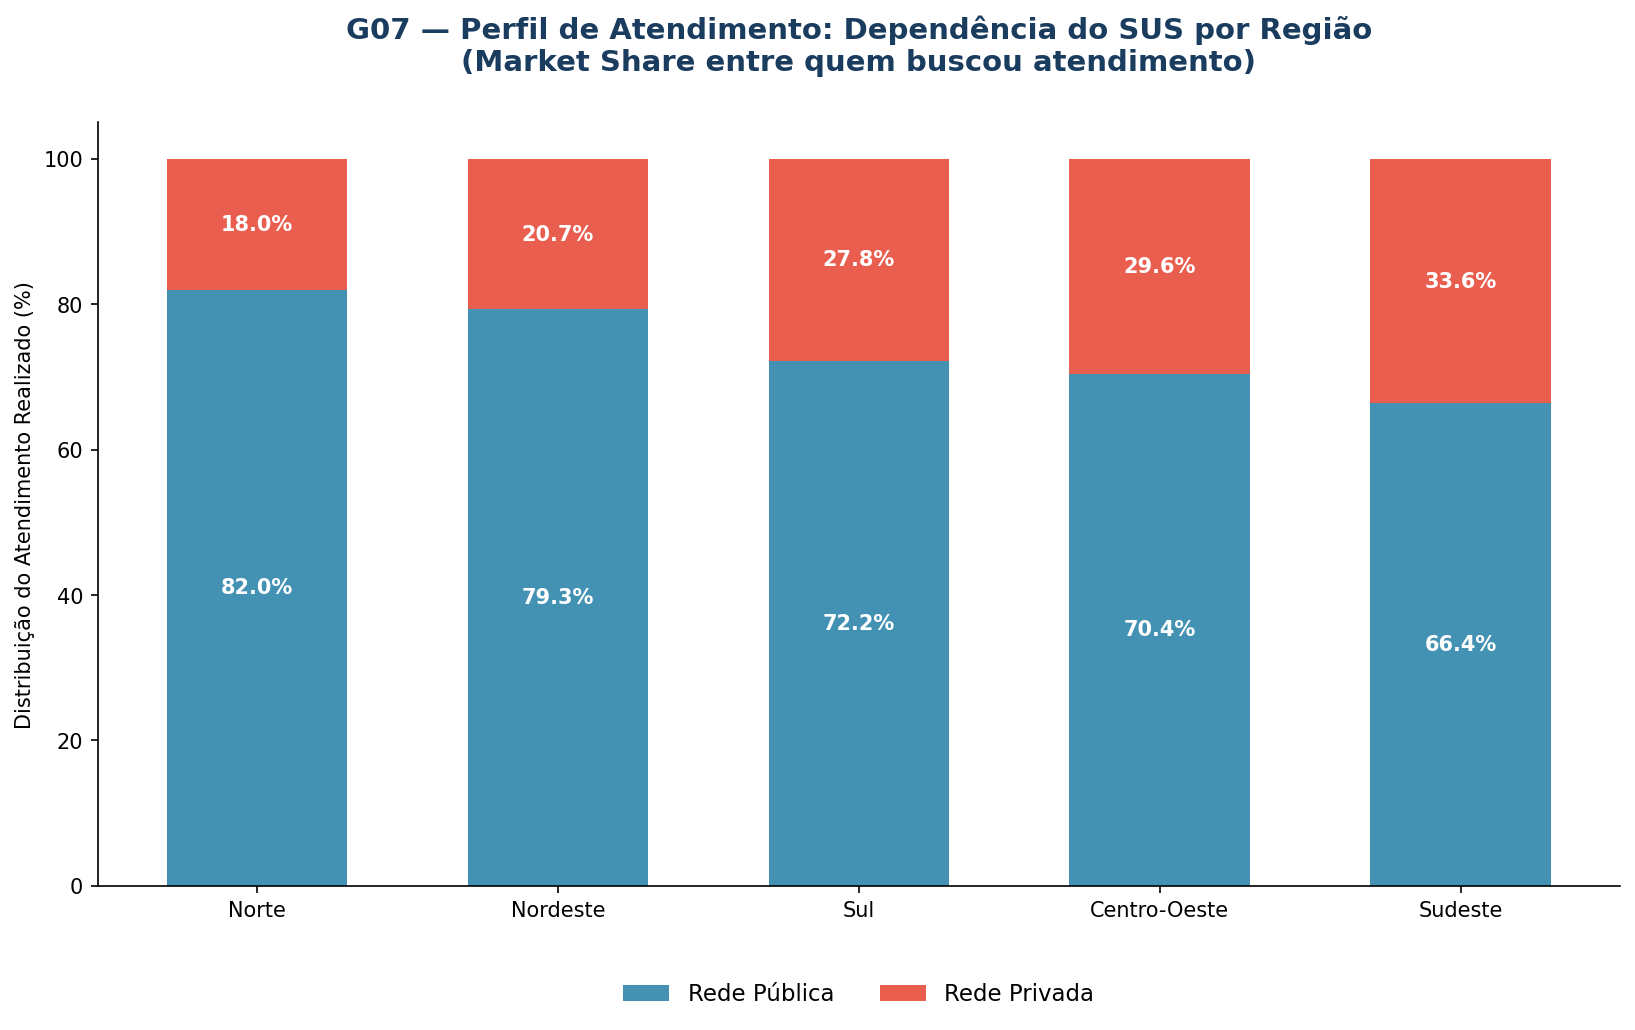

✅ G07 Final: Gráfico focado em Market Share e ordenado por dependência pública.


In [23]:
# ── G07. Composição da Demanda: SUS vs Privado (Foco em Market Share) ────────

df_g07 = q(f"""
    SELECT
        CASE
            WHEN uf IN ('Rondônia','Acre','Amazonas','Roraima','Pará','Amapá','Tocantins')
                THEN 'Norte'
            WHEN uf IN ('Maranhão','Piauí','Ceará','Rio Grande do Norte','Paraíba',
                        'Pernambuco','Alagoas','Sergipe','Bahia')
                THEN 'Nordeste'
            WHEN uf IN ('Minas Gerais','Espírito Santo','Rio de Janeiro','São Paulo')
                THEN 'Sudeste'
            WHEN uf IN ('Paraná','Santa Catarina','Rio Grande do Sul')
                THEN 'Sul'
            WHEN uf IN ('Mato Grosso do Sul','Mato Grosso','Goiás','Distrito Federal')
                THEN 'Centro-Oeste'
        END AS regiao,
        SUM(CASE WHEN atendimento_upa_sus = 'Sim' OR atendimento_hospital_sus = 'Sim' THEN 1 ELSE 0 END) AS total_sus,
        SUM(CASE WHEN atendimento_hospital_privado = 'Sim' OR atendimento_ps_privado = 'Sim' THEN 1 ELSE 0 END) AS total_privado
    FROM {TABELA}
    WHERE buscou_atendimento = 'Sim'
    GROUP BY 1
""")

# Calcula as proporções
df_g07['soma'] = df_g07['total_sus'] + df_g07['total_privado']
df_g07['pct_sus'] = (df_g07['total_sus'] / df_g07['soma']) * 100
df_g07['pct_privado'] = (df_g07['total_privado'] / df_g07['soma']) * 100

# 👉 ORDENAÇÃO: Da maior dependência do SUS para a menor
df_g07 = df_g07.sort_values('pct_sus', ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))

bar_width = 0.6
ax.bar(df_g07['regiao'], df_g07['pct_sus'], label='Rede Pública', 
       color=PALETA['azul_medio'], alpha=0.9, width=bar_width)
ax.bar(df_g07['regiao'], df_g07['pct_privado'], bottom=df_g07['pct_sus'], 
       label='Rede Privada', color=PALETA['vermelho'], alpha=0.9, width=bar_width)

# Rótulos internos (Branco para contraste)
for i, (sus, priv) in enumerate(zip(df_g07['pct_sus'], df_g07['pct_privado'])):
    ax.text(i, sus/2, f'{sus:.1f}%', ha='center', va='center', 
            color='white', fontweight='bold', fontsize=10)
    ax.text(i, sus + priv/2, f'{priv:.1f}%', ha='center', va='center', 
            color='white', fontweight='bold', fontsize=10)

ax.set_ylabel('Distribuição do Atendimento Realizado (%)', fontsize=10)
ax.set_title('G07 — Perfil de Atendimento: Dependência do SUS por Região\n(Market Share entre quem buscou atendimento)',
             fontsize=14, fontweight='bold', color=PALETA['azul_profundo'], pad=25)

# Legenda centralizada embaixo
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=11, frameon=False)

ax.set_ylim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G07_sus_vs_privado_final.png')
plt.show()

print("✅ G07 Final: Gráfico focado em Market Share e ordenado por dependência pública.")

  → Executando...
     1 linhas retornadas


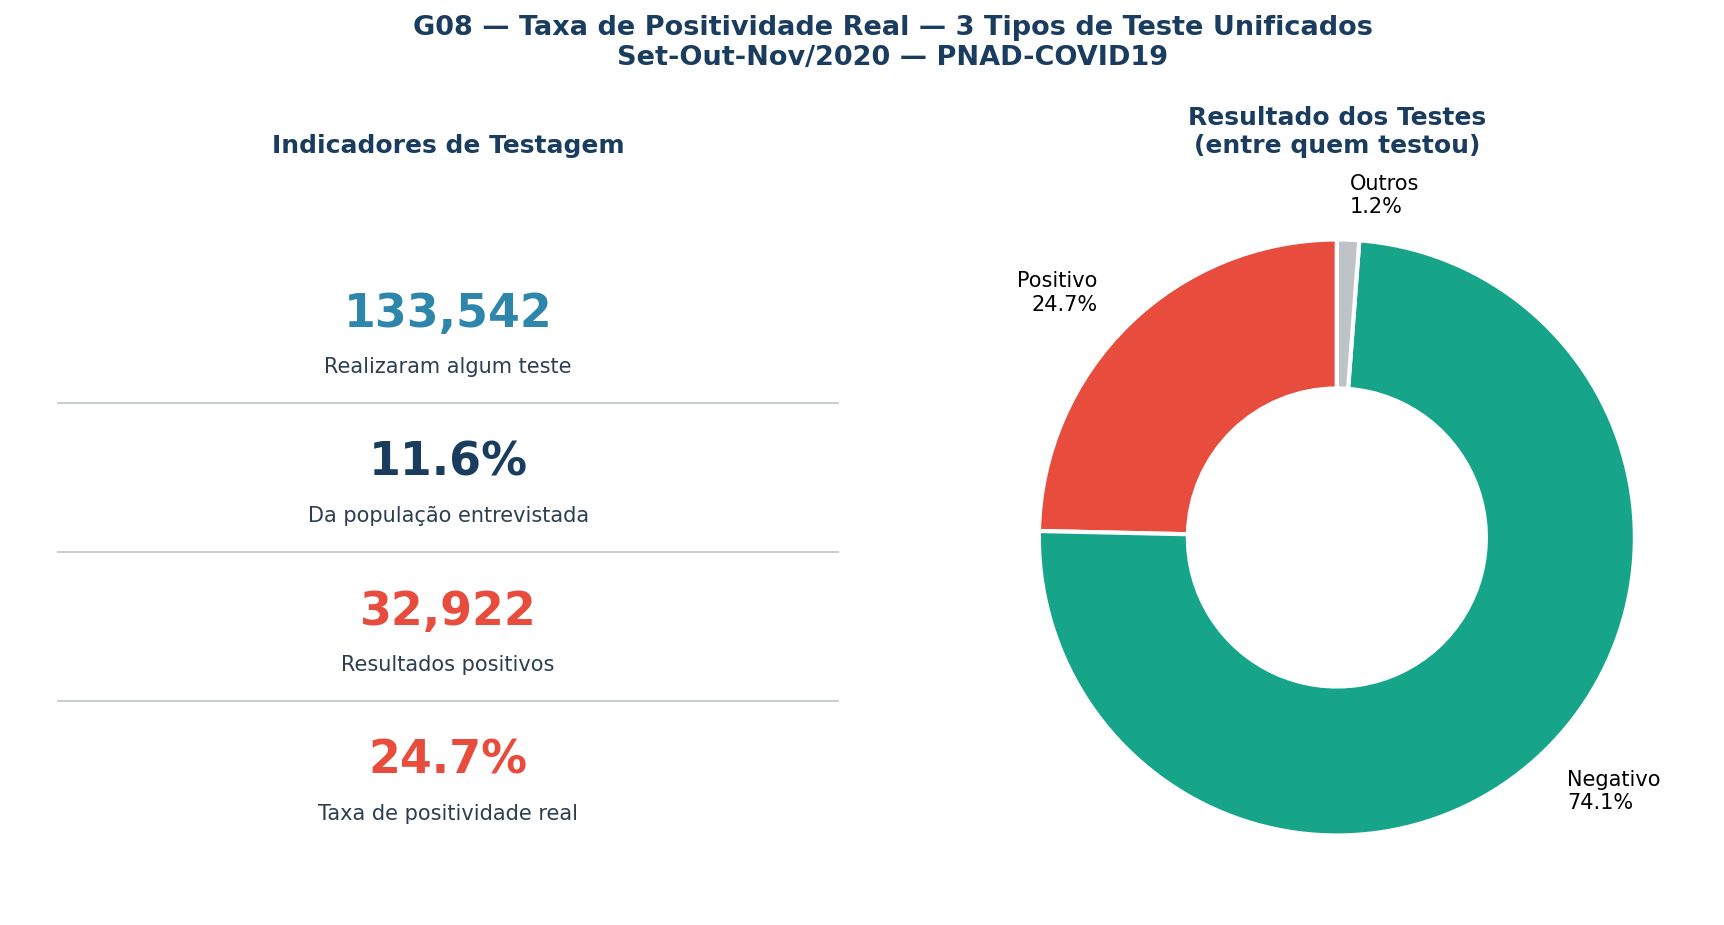

✅ G08 salvo


In [24]:
# ── G08. Positividade unificada (swab + sangue dedo + sangue veia) ────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

df_g08 = q(f"""
    SELECT
        COUNT(*) AS total_geral,
        SUM(CASE WHEN fez_teste_covid = 'Sim' THEN 1 ELSE 0 END) AS fez_teste,
        SUM(CASE WHEN resultado_teste_swab     = 'Positivo'
               OR resultado_teste_sangue_dedo = 'Positivo'
               OR resultado_teste_sangue_veia = 'Positivo' THEN 1 ELSE 0 END) AS positivos,
        SUM(CASE WHEN resultado_teste_swab     = 'Negativo'
               OR resultado_teste_sangue_dedo = 'Negativo'
               OR resultado_teste_sangue_veia = 'Negativo' THEN 1 ELSE 0 END) AS negativos,
        SUM(CASE WHEN resultado_teste_swab     = 'Inconclusivo'
               OR resultado_teste_sangue_dedo = 'Inconclusivo'
               OR resultado_teste_sangue_veia = 'Inconclusivo' THEN 1 ELSE 0 END) AS inconclusivos
    FROM {TABELA}
""")

total_geral   = int(df_g08['total_geral'].iloc[0])
total_testou  = int(df_g08['fez_teste'].iloc[0])
positivos     = int(df_g08['positivos'].iloc[0])
negativos     = int(df_g08['negativos'].iloc[0])
inconclusivos = int(df_g08['inconclusivos'].iloc[0])
nao_recebeu   = total_testou - positivos - negativos - inconclusivos

pct_testou   = total_testou / total_geral * 100   # ← agora sobre o total real
pct_positivo = positivos / total_testou * 100
pct_negativo = negativos / total_testou * 100
pct_inconcl  = inconclusivos / total_testou * 100
pct_aguardando = nao_recebeu / total_testou * 100

# ── KPIs à esquerda ──────────────────────────────────────────────────────────
ax1.axis('off')

kpis = [
    (f'{total_testou:,}',    'Realizaram algum teste',     PALETA['azul_medio']),
    (f'{pct_testou:.1f}%',   'Da população entrevistada',  PALETA['azul_profundo']),
    (f'{positivos:,}',       'Resultados positivos',       PALETA['vermelho']),
    (f'{pct_positivo:.1f}%', 'Taxa de positividade real',  PALETA['vermelho']),
]

for i, (valor, label, cor) in enumerate(kpis):
    y = 0.80 - i * 0.20
    ax1.text(0.5, y, valor,
             ha='center', va='center', fontsize=22,
             fontweight='bold', color=cor)
    ax1.text(0.5, y - 0.07, label,
             ha='center', va='center', fontsize=10,
             color=PALETA['cinza_escuro'])
    if i < len(kpis) - 1:
        ax1.axhline(y=y - 0.12, xmin=0.05, xmax=0.95,
                    color=PALETA['cinza_claro'], linewidth=0.8)

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_title('Indicadores de Testagem', fontsize=12,
              fontweight='bold', color=PALETA['azul_profundo'])

# ── Rosca à direita ───────────────────────────────────────────────────────────
pct_outros = pct_inconcl + pct_aguardando

tamanhos = [pct_positivo, pct_negativo, pct_outros]
labels_rosca = [
    f'Positivo\n{pct_positivo:.1f}%',
    f'Negativo\n{pct_negativo:.1f}%',
    f'Outros\n{pct_outros:.1f}%',
]
cores_rosca = [PALETA['vermelho'], PALETA['verde_teal'], PALETA['cinza_claro']]

wedges, texts = ax2.pie(
    tamanhos,
    labels=labels_rosca,
    colors=cores_rosca,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10),
    labeldistance=1.15,
)

ax2.set_title('Resultado dos Testes\n(entre quem testou)', fontsize=12,
              fontweight='bold', color=PALETA['azul_profundo'])

fig.suptitle('G08 — Taxa de Positividade Real — 3 Tipos de Teste Unificados\nSet-Out-Nov/2020 — PNAD-COVID19',
             fontsize=13, fontweight='bold', color=PALETA['azul_profundo'], y=1.02)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G08_positividade_testes.png')
plt.show()
print("✅ G08 salvo")

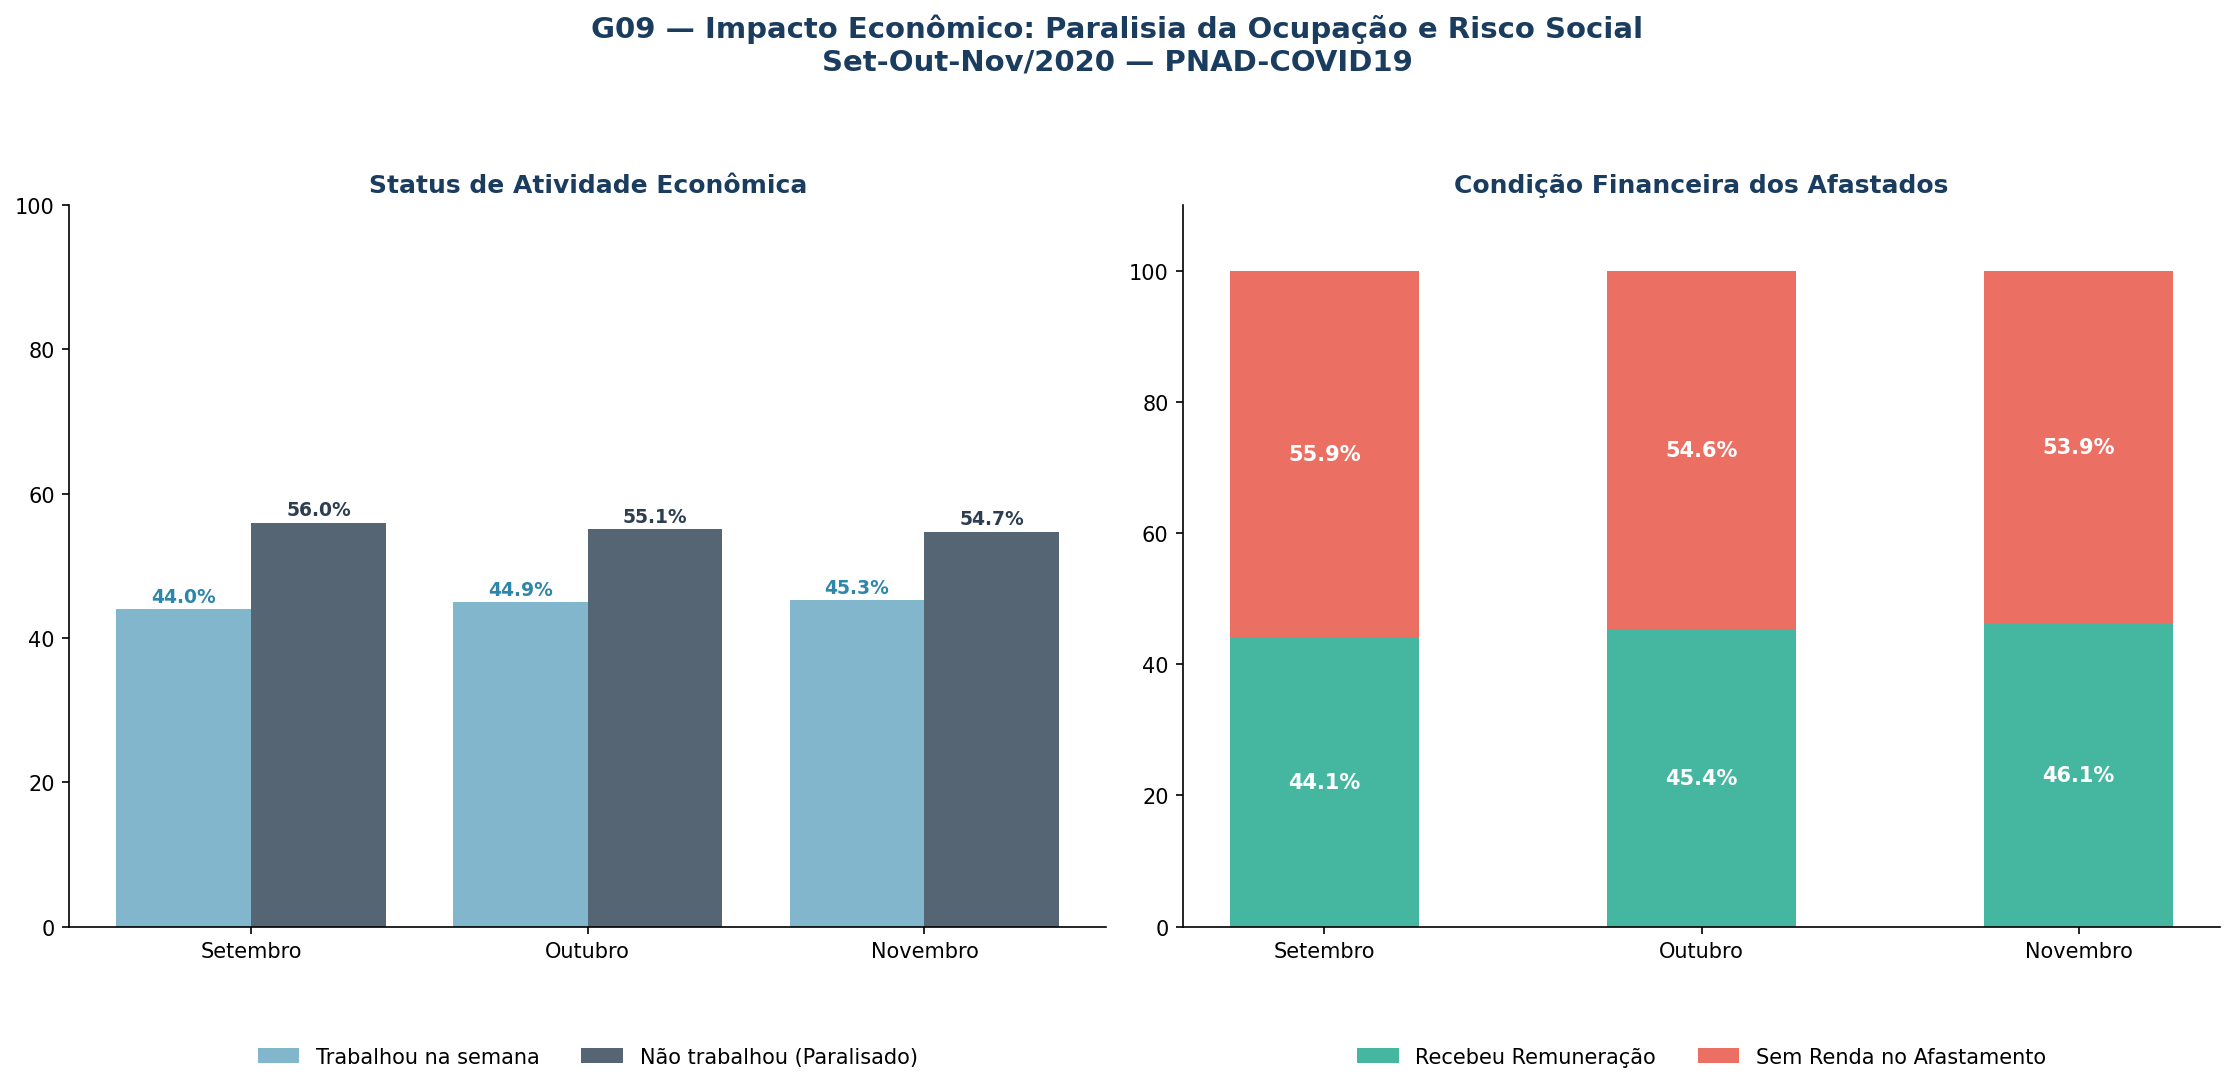

In [28]:
# ── G09. Impacto Econômico: Vulnerabilidade de Ocupação e Renda ──────────────

# SQL e Processamento permanecem os mesmos da versão anterior (consolidada)
# ...

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# ── PAINEL 1: Ocupação (Foco no Impacto da Paralisia) ────────────────────────
# Inverti as cores para dar destaque ao "Não Trabalhou", que é o foco da crise
b1 = ax1.bar(x - width/2, df_g09['pct_trabalhou'], width, 
             label='Trabalhou na semana', color=PALETA['azul_medio'], alpha=0.6)
b2 = ax1.bar(x + width/2, df_g09['pct_nao_trabalhou'], width, 
             label='Não trabalhou (Paralisado)', color=PALETA['cinza_escuro'], alpha=0.8)

for i, val in enumerate(df_g09['pct_trabalhou']):
    ax1.text(i - width/2, val + 1, f'{val:.1f}%', ha='center', fontsize=9, color=PALETA['azul_medio'], fontweight='bold')
for i, val in enumerate(df_g09['pct_nao_trabalhou']):
    ax1.text(i + width/2, val + 1, f'{val:.1f}%', ha='center', fontsize=9, color=PALETA['cinza_escuro'], fontweight='bold')

ax1.set_title('Status de Atividade Econômica', fontsize=12, fontweight='bold', color=PALETA['azul_profundo'])
ax1.set_ylim(0, 100)

# ── PAINEL 2: Composição da Renda (Vulnerabilidade) ─────────────────────────
# Mantemos a versão consolidada (2 cores) que ficou excelente
ax2.bar(df_g09['mes_label'], df_g09['pct_remunerado'], label='Recebeu Remuneração', 
        color=PALETA['verde_teal'], alpha=0.8, width=0.5)
ax2.bar(df_g09['mes_label'], df_g09['pct_sem_renda'], bottom=df_g09['pct_remunerado'], 
        label='Sem Renda no Afastamento', color=PALETA['vermelho'], alpha=0.8, width=0.5)

for i, (rem, sem_r) in enumerate(zip(df_g09['pct_remunerado'], df_g09['pct_sem_renda'])):
    ax2.text(i, rem/2, f'{rem:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    ax2.text(i, rem + sem_r/2, f'{sem_r:.1f}%', ha='center', va='center', color='white', fontweight='bold')

ax2.set_title('Condição Financeira dos Afastados', fontsize=12, fontweight='bold', color=PALETA['azul_profundo'])
ax2.set_ylim(0, 110)

# Estética Final
for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(df_g09['mes_label'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False, fontsize=10)

fig.suptitle('G09 — Impacto Econômico: Paralisia da Ocupação e Risco Social\nSet-Out-Nov/2020 — PNAD-COVID19',
             fontsize=14, fontweight='bold', color=PALETA['azul_profundo'], y=1.05)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G09_impacto_economico_final.png')
plt.show()

  → Executando...
     5 linhas retornadas


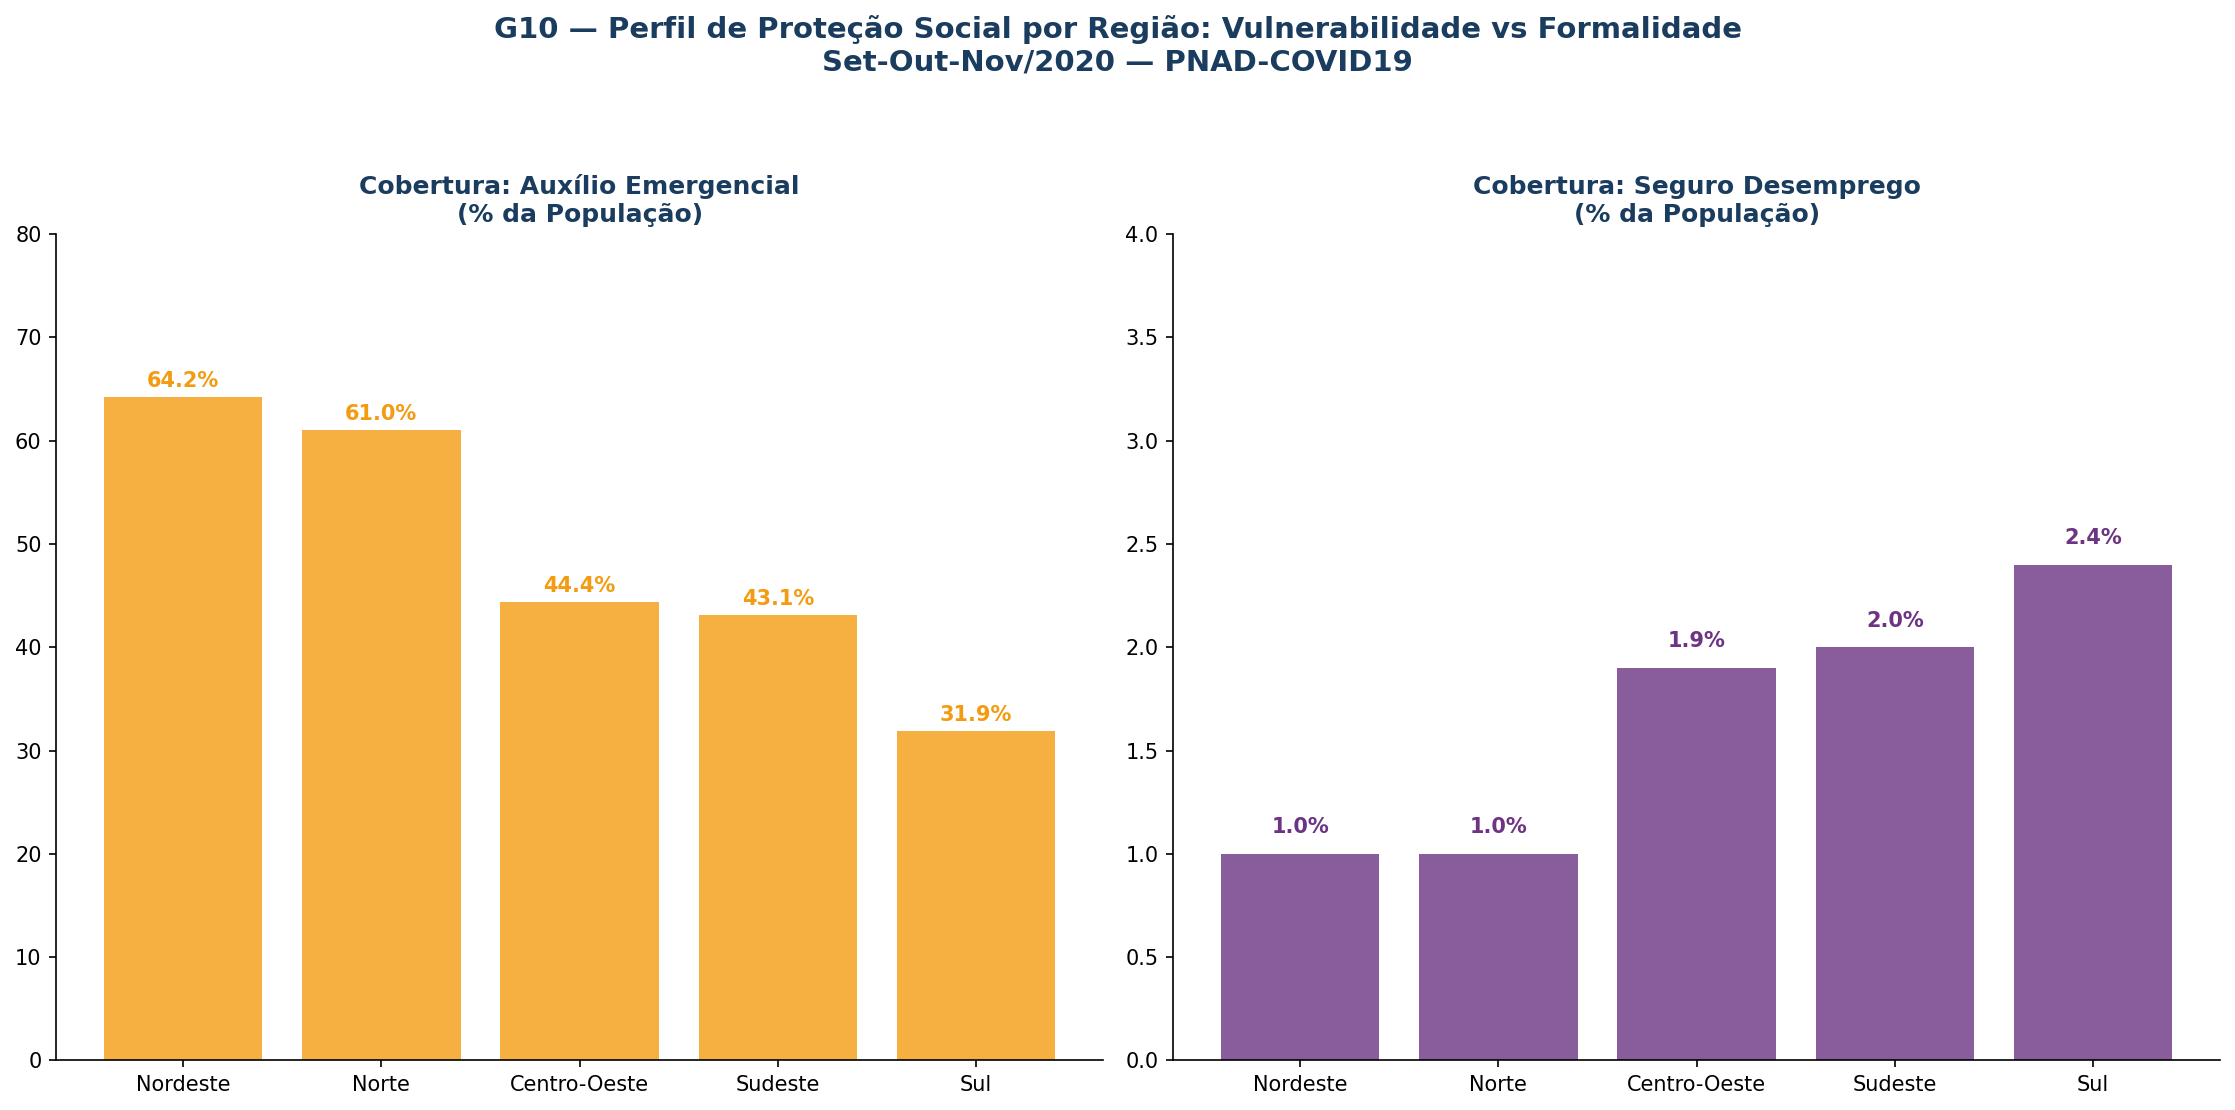

✅ G10 atualizado: Visão comparativa com escalas ajustadas para cada benefício.


In [30]:
# ── G10. Disparidade de Proteção Social: Auxílio vs Seguro Desemprego ────────

# A query SQL permanece a mesma (está correta e eficiente)
df_g10 = q(f"""
    SELECT
        CASE
            WHEN uf IN ('Rondônia','Acre','Amazonas','Roraima','Pará','Amapá','Tocantins') THEN 'Norte'
            WHEN uf IN ('Maranhão','Piauí','Ceará','Rio Grande do Norte','Paraíba','Pernambuco','Alagoas','Sergipe','Bahia') THEN 'Nordeste'
            WHEN uf IN ('Minas Gerais','Espírito Santo','Rio de Janeiro','São Paulo') THEN 'Sudeste'
            WHEN uf IN ('Paraná','Santa Catarina','Rio Grande do Sul') THEN 'Sul'
            WHEN uf IN ('Mato Grosso do Sul','Mato Grosso','Goiás','Distrito Federal') THEN 'Centro-Oeste'
        END AS regiao,
        ROUND(100.0 * SUM(CASE WHEN recebeu_auxilio_emergencial = 'Sim' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_auxilio,
        ROUND(100.0 * SUM(CASE WHEN recebeu_seguro_desemprego = 'Sim' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_seguro
    FROM {TABELA}
    GROUP BY 1
""")

# Ordenação por maior dependência de Auxílio (Norte/Nordeste no topo)
df_g10 = df_g10.sort_values('pct_auxilio', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=False)

# ── Painel 1: Auxílio Emergencial (Proteção à Vulnerabilidade) ──────────────
b1 = ax1.bar(df_g10['regiao'], df_g10['pct_auxilio'], color=PALETA['ambar'], alpha=0.8)
ax1.set_title('Cobertura: Auxílio Emergencial\n(% da População)', fontsize=12, fontweight='bold', color=PALETA['azul_profundo'])
ax1.set_ylim(0, 80) # Escala fixa para mostrar a magnitude

for bar in b1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', fontweight='bold', color=PALETA['ambar'])

# ── Painel 2: Seguro Desemprego (Impacto no Mercado Formal) ──────────────────
# Note que aqui a escala será menor (ex: 0 a 5%) para podermos ver a diferença regional
b2 = ax2.bar(df_g10['regiao'], df_g10['pct_seguro'], color=PALETA['roxo'], alpha=0.8)
ax2.set_title('Cobertura: Seguro Desemprego\n(% da População)', fontsize=12, fontweight='bold', color=PALETA['azul_profundo'])
ax2.set_ylim(0, 4) # Escala ajustada para o dado menor

for bar in b2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{h:.1f}%', ha='center', fontweight='bold', color=PALETA['roxo'])

# Ajustes Finais (Respeitando rcParams do projeto)
fig.suptitle('G10 — Perfil de Proteção Social por Região: Vulnerabilidade vs Formalidade\nSet-Out-Nov/2020 — PNAD-COVID19',
             fontsize=14, fontweight='bold', color=PALETA['azul_profundo'], y=1.05)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G10_beneficios_sociais_refinado.png')
plt.show()

print("✅ G10 atualizado: Visão comparativa com escalas ajustadas para cada benefício.")

  → Executando...
     27 linhas retornadas


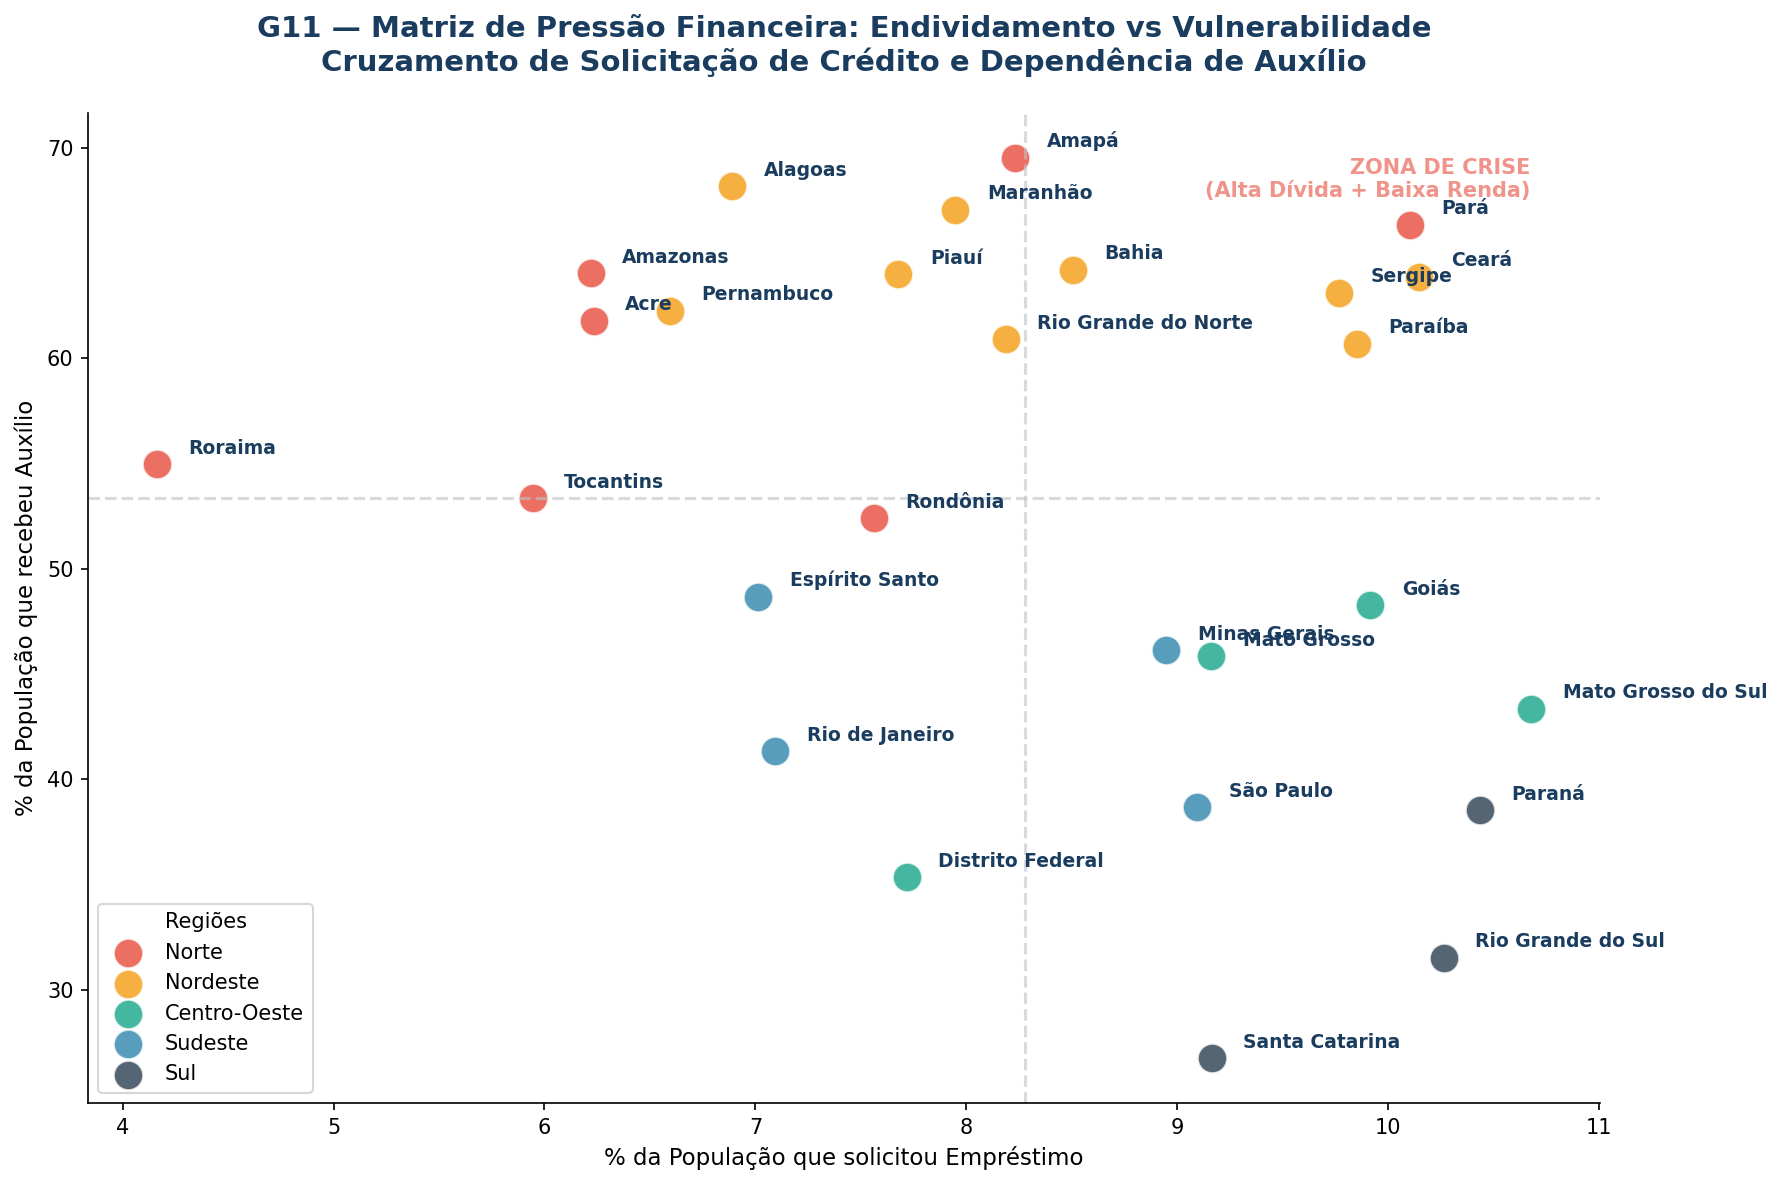

In [33]:
# ── G11. Matriz de Vulnerabilidade Financeira: Endividamento vs Dependência ──

df_g11 = q(f"""
    SELECT
        uf,
        CASE
            WHEN uf IN ('Rondônia','Acre','Amazonas','Roraima','Pará','Amapá','Tocantins') THEN 'Norte'
            WHEN uf IN ('Maranhão','Piauí','Ceará','Rio Grande do Norte','Paraíba','Pernambuco','Alagoas','Sergipe','Bahia') THEN 'Nordeste'
            WHEN uf IN ('Minas Gerais','Espírito Santo','Rio de Janeiro','São Paulo') THEN 'Sudeste'
            WHEN uf IN ('Paraná','Santa Catarina','Rio Grande do Sul') THEN 'Sul'
            WHEN uf IN ('Mato Grosso do Sul','Mato Grosso','Goiás','Distrito Federal') THEN 'Centro-Oeste'
        END AS regiao,
        AVG(CASE WHEN UPPER(TRIM(solicitou_emprestimo)) LIKE 'SIM%' THEN 100.0 ELSE 0.0 END) AS pct_emprestimo,
        AVG(CASE WHEN UPPER(TRIM(recebeu_auxilio_emergencial)) = 'SIM' THEN 100.0 ELSE 0.0 END) AS pct_auxilio
    FROM {TABELA}
    WHERE solicitou_emprestimo IS NOT NULL 
      AND recebeu_auxilio_emergencial IS NOT NULL
    GROUP BY 1, 2
""")

fig, ax = plt.subplots(figsize=(12, 8))

# Cores por região para manter a identidade
cores_regiao = {
    'Norte': PALETA['vermelho'], 'Nordeste': PALETA['ambar'], 
    'Centro-Oeste': PALETA['verde_teal'], 'Sudeste': PALETA['azul_medio'], 'Sul': PALETA['cinza_escuro']
}

# Plot dos pontos
for reg, cor in cores_regiao.items():
    mask = df_g11['regiao'] == reg
    ax.scatter(df_g11.loc[mask, 'pct_emprestimo'], df_g11.loc[mask, 'pct_auxilio'], 
               color=cor, s=200, label=reg, alpha=0.8, edgecolor='white', linewidth=1)

# Linhas de média (Quadrantes)
med_emp = df_g11['pct_emprestimo'].mean()
med_aux = df_g11['pct_auxilio'].mean()
ax.axvline(med_emp, color=PALETA['cinza_claro'], linestyle='--', alpha=0.6, zorder=1)
ax.axhline(med_aux, color=PALETA['cinza_claro'], linestyle='--', alpha=0.6, zorder=1)

# Rótulos dos estados (com ajuste para não sobrepor)
for i, row in df_g11.iterrows():
    ax.text(row['pct_emprestimo'] + 0.15, row['pct_auxilio'] + 0.5, row['uf'], 
            fontsize=9, fontweight='bold', color=PALETA['azul_profundo'])

# Títulos e Anotações de Quadrante
ax.set_title('G11 — Matriz de Pressão Financeira: Endividamento vs Vulnerabilidade\nCruzamento de Solicitação de Crédito e Dependência de Auxílio', 
             fontsize=14, fontweight='bold', color=PALETA['azul_profundo'], pad=20)

ax.set_xlabel('% da População que solicitou Empréstimo', fontsize=11)
ax.set_ylabel('% da População que recebeu Auxílio', fontsize=11)

# Texto explicativo nos quadrantes
ax.text(df_g11['pct_emprestimo'].max(), df_g11['pct_auxilio'].max(), 'ZONA DE CRISE\n(Alta Dívida + Baixa Renda)', 
        ha='right', va='top', fontsize=10, color=PALETA['vermelho'], fontweight='bold', alpha=0.6)

ax.legend(title="Regiões", loc='lower left', frameon=True)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G11_matriz_vulnerabilidade_financeira.png')
plt.show()

  → Executando...
     27 linhas retornadas


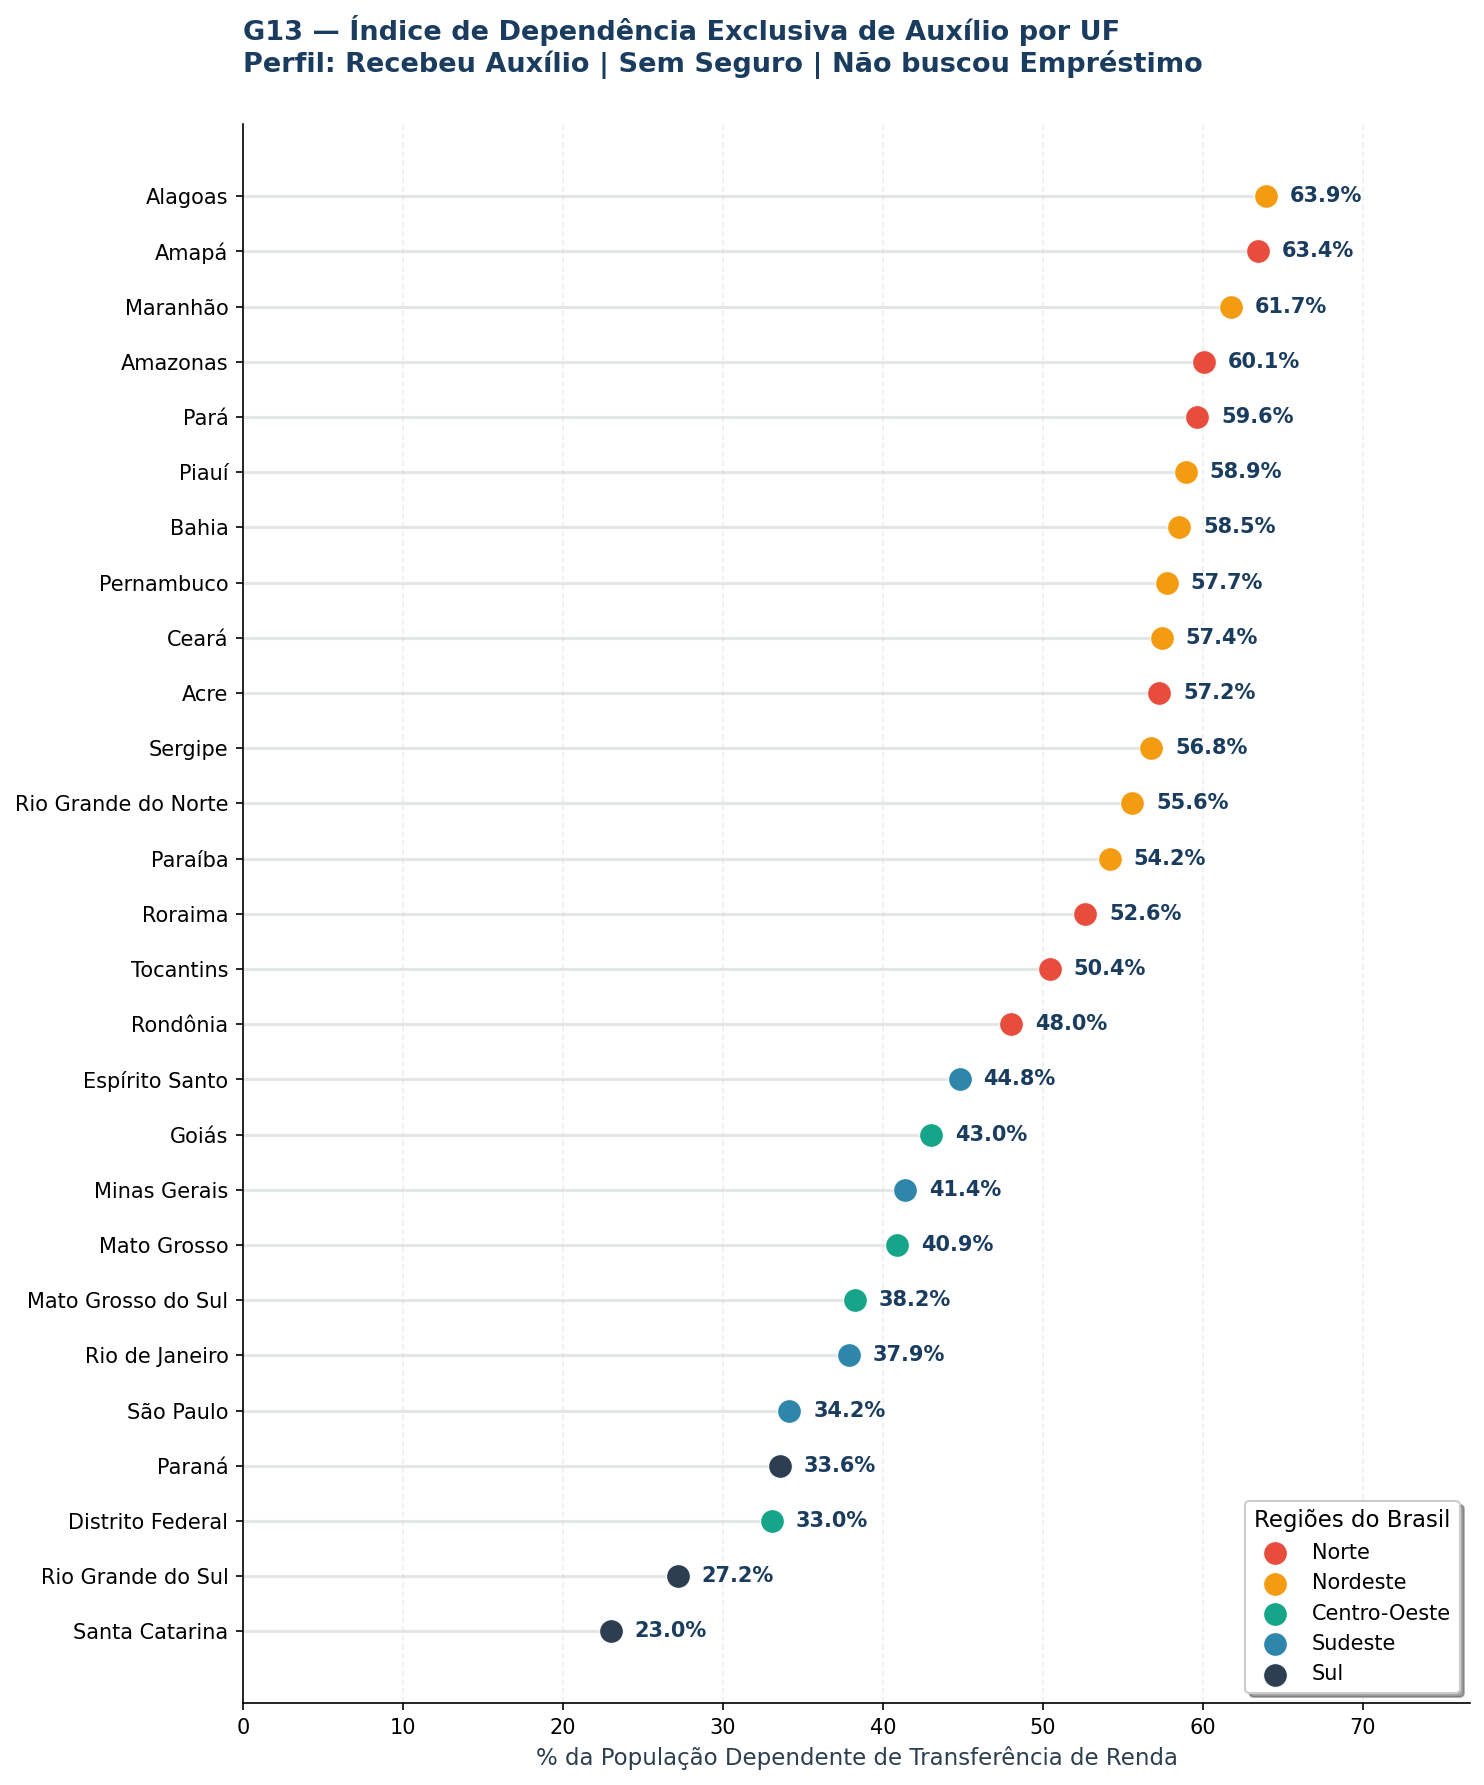

✅ Pipeline finalizado! G11 (P15) gerado e salvo.


In [36]:
# ── G11. Índice de Dependência Exclusiva de Auxílio por UF e Região ────────────────────

# SQL consolidado para a métrica de Dependência Exclusiva
df_g11 = q(f"""
    SELECT
        uf,
        CASE
            WHEN uf IN ('Rondônia','Acre','Amazonas','Roraima','Pará','Amapá','Tocantins') THEN 'Norte'
            WHEN uf IN ('Maranhão','Piauí','Ceará','Rio Grande do Norte','Paraíba','Pernambuco','Alagoas','Sergipe','Bahia') THEN 'Nordeste'
            WHEN uf IN ('Minas Gerais','Espírito Santo','Rio de Janeiro','São Paulo') THEN 'Sudeste'
            WHEN uf IN ('Paraná','Santa Catarina','Rio Grande do Sul') THEN 'Sul'
            WHEN uf IN ('Mato Grosso do Sul','Mato Grosso','Goiás','Distrito Federal') THEN 'Centro-Oeste'
        END AS regiao,
        AVG(CASE 
            WHEN UPPER(TRIM(recebeu_auxilio_emergencial)) = 'SIM'
             AND UPPER(TRIM(recebeu_seguro_desemprego)) = 'NÃO'
             AND UPPER(TRIM(solicitou_emprestimo)) = 'NÃO SOLICITOU'
            THEN 100.0 ELSE 0.0 END) AS pct_dependencia_auxilio
    FROM {TABELA}
    WHERE recebeu_auxilio_emergencial IS NOT NULL 
      AND recebeu_seguro_desemprego IS NOT NULL
      AND solicitou_emprestimo IS NOT NULL
    GROUP BY 1, 2
    ORDER BY pct_dependencia_auxilio ASC
""")

# Mapeamento de cores por região (PALETA oficial)
cores_regiao = {
    'Norte':        PALETA['vermelho'],
    'Nordeste':     PALETA['ambar'],
    'Centro-Oeste': PALETA['verde_teal'],
    'Sudeste':      PALETA['azul_medio'],
    'Sul':          PALETA['cinza_escuro']
}

fig, ax = plt.subplots(figsize=(10, 12))

# Linhas de conexão do Lollipop
ax.hlines(y=df_g11['uf'], xmin=0, xmax=df_g11['pct_dependencia_auxilio'], 
          color=PALETA['cinza_claro'], alpha=0.4, linewidth=1.5)

# Plot dos pontos coloridos por região
for reg, cor in cores_regiao.items():
    mask = df_g11['regiao'] == reg
    ax.scatter(df_g11.loc[mask, 'pct_dependencia_auxilio'], df_g11.loc[mask, 'uf'], 
               color=cor, s=130, label=reg, zorder=3, edgecolor='white', linewidth=0.5)

# Rótulos de dados (Ajuste do offset de 0.3 para 1.5)
for i, row in df_g11.iterrows():
    ax.text(row['pct_dependencia_auxilio'] + 1.5, i, f"{row['pct_dependencia_auxilio']:.1f}%", 
            va='center', fontsize=10, fontweight='bold', color=PALETA['azul_profundo'])

# Aumentamos um pouco o limite do eixo X para o texto não ser cortado na borda
ax.set_xlim(0, df_g11['pct_dependencia_auxilio'].max() * 1.25)

# Títulos e Labels customizados para P15
ax.set_title('G13 — Índice de Dependência Exclusiva de Auxílio por UF\nPerfil: Recebeu Auxílio | Sem Seguro | Não buscou Empréstimo', 
             fontsize=13, fontweight='bold', color=PALETA['azul_profundo'], pad=25, loc='left')

ax.set_xlabel('% da População Dependente de Transferência de Renda', fontsize=11, color=PALETA['cinza_escuro'])
ax.set_xlim(0, df_g11['pct_dependencia_auxilio'].max() * 1.2)


# Legenda com as Regiões
ax.legend(title="Regiões do Brasil", title_fontsize=11, fontsize=10, 
          loc='lower right', frameon=True, shadow=True)

# Grid discreta para o eixo X
ax.grid(axis='x', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G11_dependencia_auxilio_P15.png')
plt.show()

print("✅ Pipeline finalizado! G11 (P15) gerado e salvo.")

  → Executando...
     25 linhas retornadas


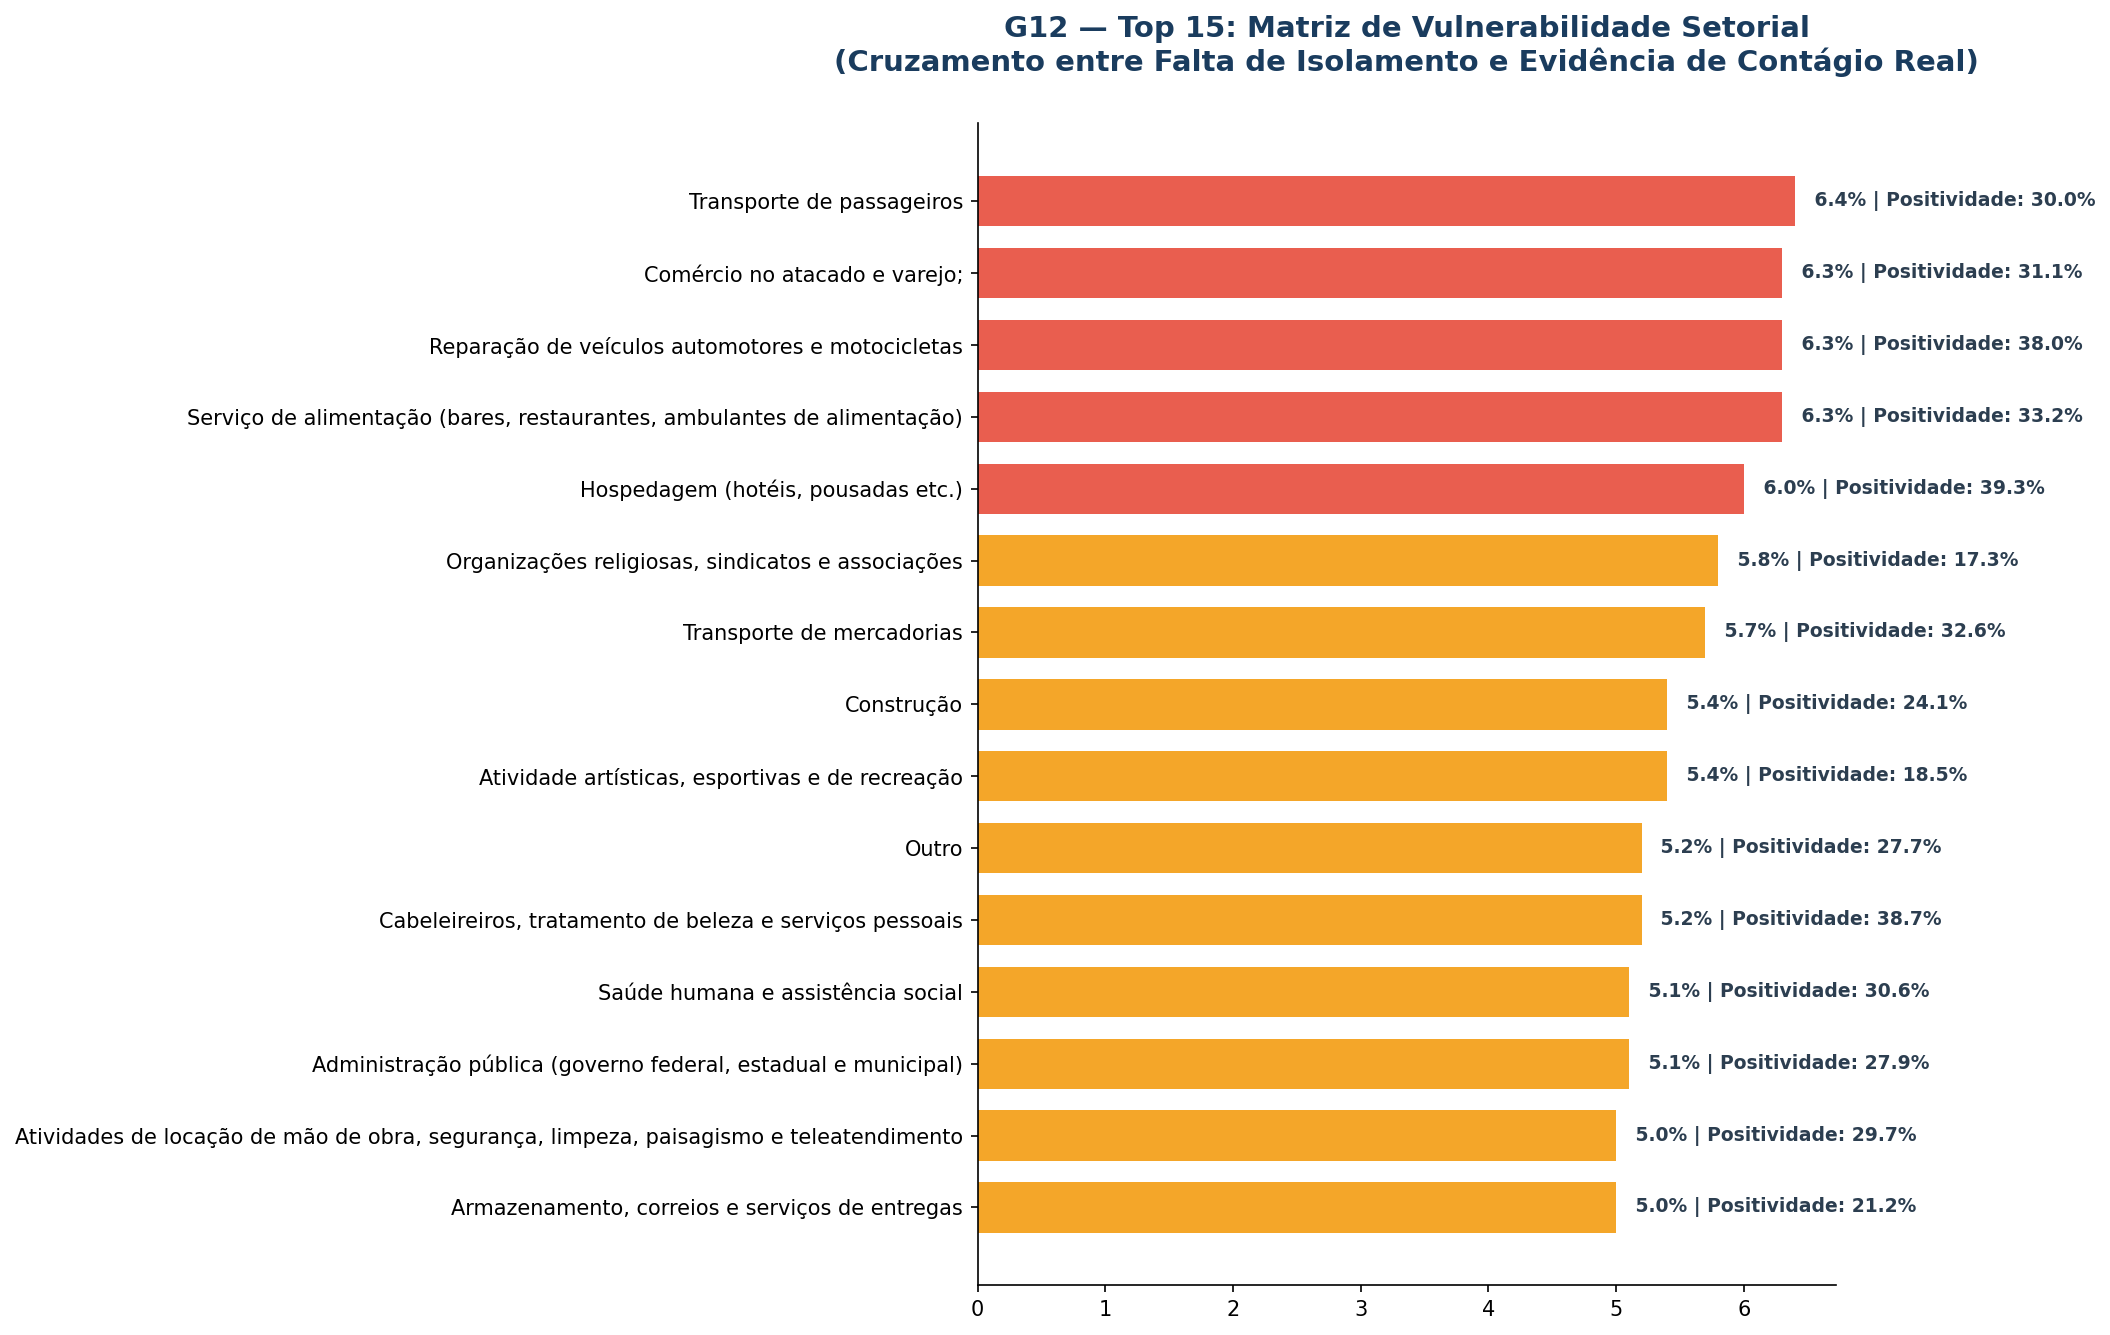

✅ G12 Finalizado: Top 15 gerado com foco na Matriz de Risco.


In [38]:
# ── G12. Matriz de Risco: Top 15 Setores de Maior Vulnerabilidade ──────────

df_g12 = q(f"""
    SELECT
        setor_atividade_empresa,
        -- Indicador 1: Exposição Comportamental (% sem isolamento)
        ROUND(100.0 * SUM(CASE WHEN nivel_isolamento = 'Não fez restrição, levou vida normal como antes da pandemia'
                 THEN 1 ELSE 0 END) / NULLIF(COUNT(*), 0), 1) AS pct_sem_isolamento,
        -- Indicador 2: Evidência de Contágio (% Positivos entre os testados)
        ROUND(100.0 * SUM(CASE WHEN resultado_teste_swab = 'Positivo' THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN resultado_teste_swab IN ('Positivo', 'Negativo') THEN 1 ELSE 0 END), 0), 1) AS taxa_positi
    FROM {TABELA}
    WHERE setor_atividade_empresa IS NOT NULL
      AND trabalhou_semana = 'Sim'
    GROUP BY setor_atividade_empresa
    HAVING COUNT(*) > 1000
""")

# Lógica de Classificação Multidimensional
def definir_risco(row):
    # CRÍTICO: Alta Positividade (>29%) E Exposição Significativa (>5.9%)
    if row['taxa_positi'] > 29 and row['pct_sem_isolamento'] > 5.9:
        return 'Crítico', PALETA['vermelho']
    # MODERADO: Cruzamento intermediário
    elif row['taxa_positi'] > 14 and row['pct_sem_isolamento'] > 2.9:
        return 'Moderado', PALETA['ambar']
    else:
        return 'Controlado', PALETA['azul_medio']

df_g12[['nivel_risco', 'cor']] = df_g12.apply(
    lambda row: pd.Series(definir_risco(row)), axis=1
)

# 👉 ORDENAÇÃO E FILTRO TOP 15: Foco nos setores de maior impacto
# Ordenamos primeiro pela cor (Críticos no topo) e depois pela exposição
df_g12 = df_g12.sort_values(['cor', 'pct_sem_isolamento'], ascending=[False, True])
df_g12 = df_g12.tail(15) # Pegamos os 15 do topo da lista de risco (ordem barh é de baixo para cima)

fig, ax = plt.subplots(figsize=(14, 9))

bars = ax.barh(df_g12['setor_atividade_empresa'], df_g12['pct_sem_isolamento'], 
               color=df_g12['cor'], height=0.7, alpha=0.9)

# Rótulo de dados inteligente
for bar, val_exp, val_pos in zip(bars, df_g12['pct_sem_isolamento'], df_g12['taxa_positi']):
    label_pos = f' | Positividade: {val_pos}%' if not np.isnan(val_pos) else ''
    ax.text(val_exp + 0.1, bar.get_y() + bar.get_height() / 2,
            f' {val_exp}%{label_pos}', va='center', fontsize=9,
            color=PALETA['cinza_escuro'], fontweight='bold')

ax.set_title('G12 — Top 15: Matriz de Vulnerabilidade Setorial\n(Cruzamento entre Falta de Isolamento e Evidência de Contágio Real)',
             fontsize=14, fontweight='bold', color=PALETA['azul_profundo'], pad=25)

# # Legenda estratégica
# import matplotlib.patches as mpatches
# leg_at = [
#     mpatches.Patch(color=PALETA['vermelho'], label='CRÍTICO: Exposição Severa + Alta Positividade'),
#     mpatches.Patch(color=PALETA['ambar'],    label='MODERADO: Exposição Intermediária')
# ]
# ax.legend(handles=leg_at, loc='lower left', title="Critério de Gestão de Risco", frameon=True, fontsize=10)

# ax.set_xlabel('% de trabalhadores sem isolamento no setor', fontsize=11, labelpad=10)
# ax.set_xlim(0, df_g12['pct_sem_isolamento'].max() * 1.45)
# ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G12_matriz_risco_top15.png')
plt.show()

print("✅ G12 Finalizado: Top 15 gerado com foco na Matriz de Risco.")

  → Executando...
     12 linhas retornadas


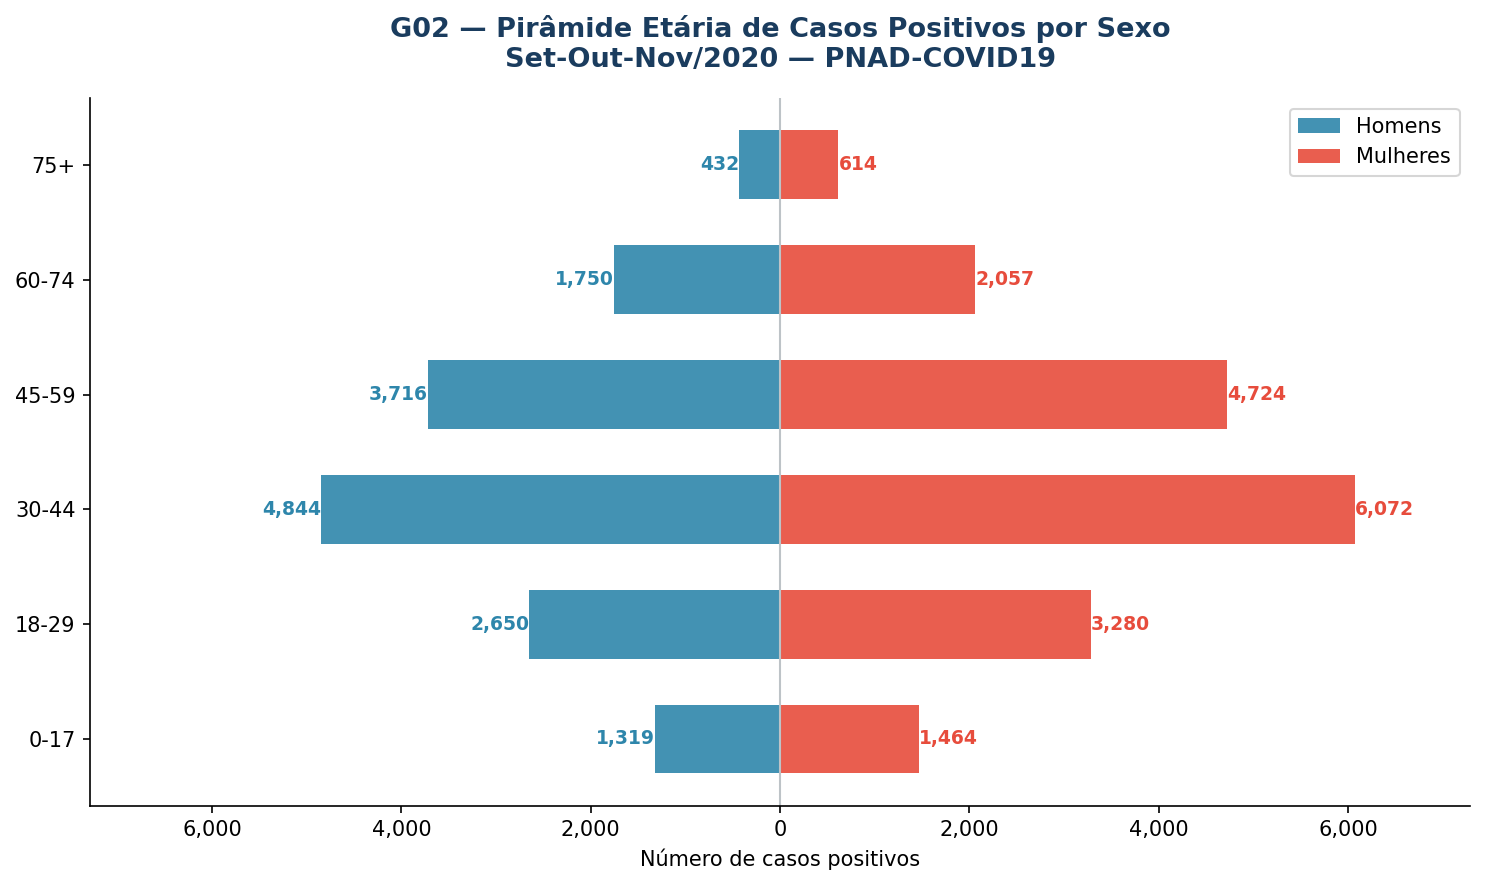

✅ G02 salvo


In [40]:
# ── G02. Pirâmide etária — positivos por faixa etária e sexo ─────────────────

df_g02 = q(f"""
    SELECT
        CASE
            WHEN CAST(idade AS INT) < 18 THEN '0-17'
            WHEN CAST(idade AS INT) < 30 THEN '18-29'
            WHEN CAST(idade AS INT) < 45 THEN '30-44'
            WHEN CAST(idade AS INT) < 60 THEN '45-59'
            WHEN CAST(idade AS INT) < 75 THEN '60-74'
            ELSE '75+'
        END AS faixa_etaria,
        sexo,
        COUNT(*) AS total
    FROM {TABELA}
    WHERE (resultado_teste_swab        = 'Positivo'
        OR resultado_teste_sangue_dedo = 'Positivo'
        OR resultado_teste_sangue_veia = 'Positivo')
      AND sexo IS NOT NULL
      AND idade IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1
""")

ordem_faixas = ['0-17', '18-29', '30-44', '45-59', '60-74', '75+']

homens   = df_g02[df_g02['sexo'] == 'Homem'].set_index('faixa_etaria').reindex(ordem_faixas)['total'].fillna(0)
mulheres = df_g02[df_g02['sexo'] == 'Mulher'].set_index('faixa_etaria').reindex(ordem_faixas)['total'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(ordem_faixas, -homens,   color=PALETA['azul_medio'], alpha=0.9, label='Homens',   height=0.6)
ax.barh(ordem_faixas,  mulheres, color=PALETA['vermelho'],   alpha=0.9, label='Mulheres', height=0.6)

for i, (h, m) in enumerate(zip(homens, mulheres)):
    ax.text(-h - 2, i, f'{int(h):,}', va='center', ha='right',
            fontsize=9, color=PALETA['azul_medio'], fontweight='bold')
    ax.text(m + 2,  i, f'{int(m):,}', va='center', ha='left',
            fontsize=9, color=PALETA['vermelho'],   fontweight='bold')

ax.set_xlabel('Número de casos positivos', fontsize=10)
ax.set_title('G02 — Pirâmide Etária de Casos Positivos por Sexo\nSet-Out-Nov/2020 — PNAD-COVID19',
             fontsize=13, fontweight='bold', color=PALETA['azul_profundo'], pad=15)

max_val = max(homens.max(), mulheres.max()) * 1.2
ax.set_xlim(-max_val, max_val)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(int(x)):,}'))

ax.axvline(0, color=PALETA['cinza_claro'], linewidth=1)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G02_piramide_etaria.png')
plt.show()
print("✅ G02 salvo")

  → Executando...
     27 linhas retornadas


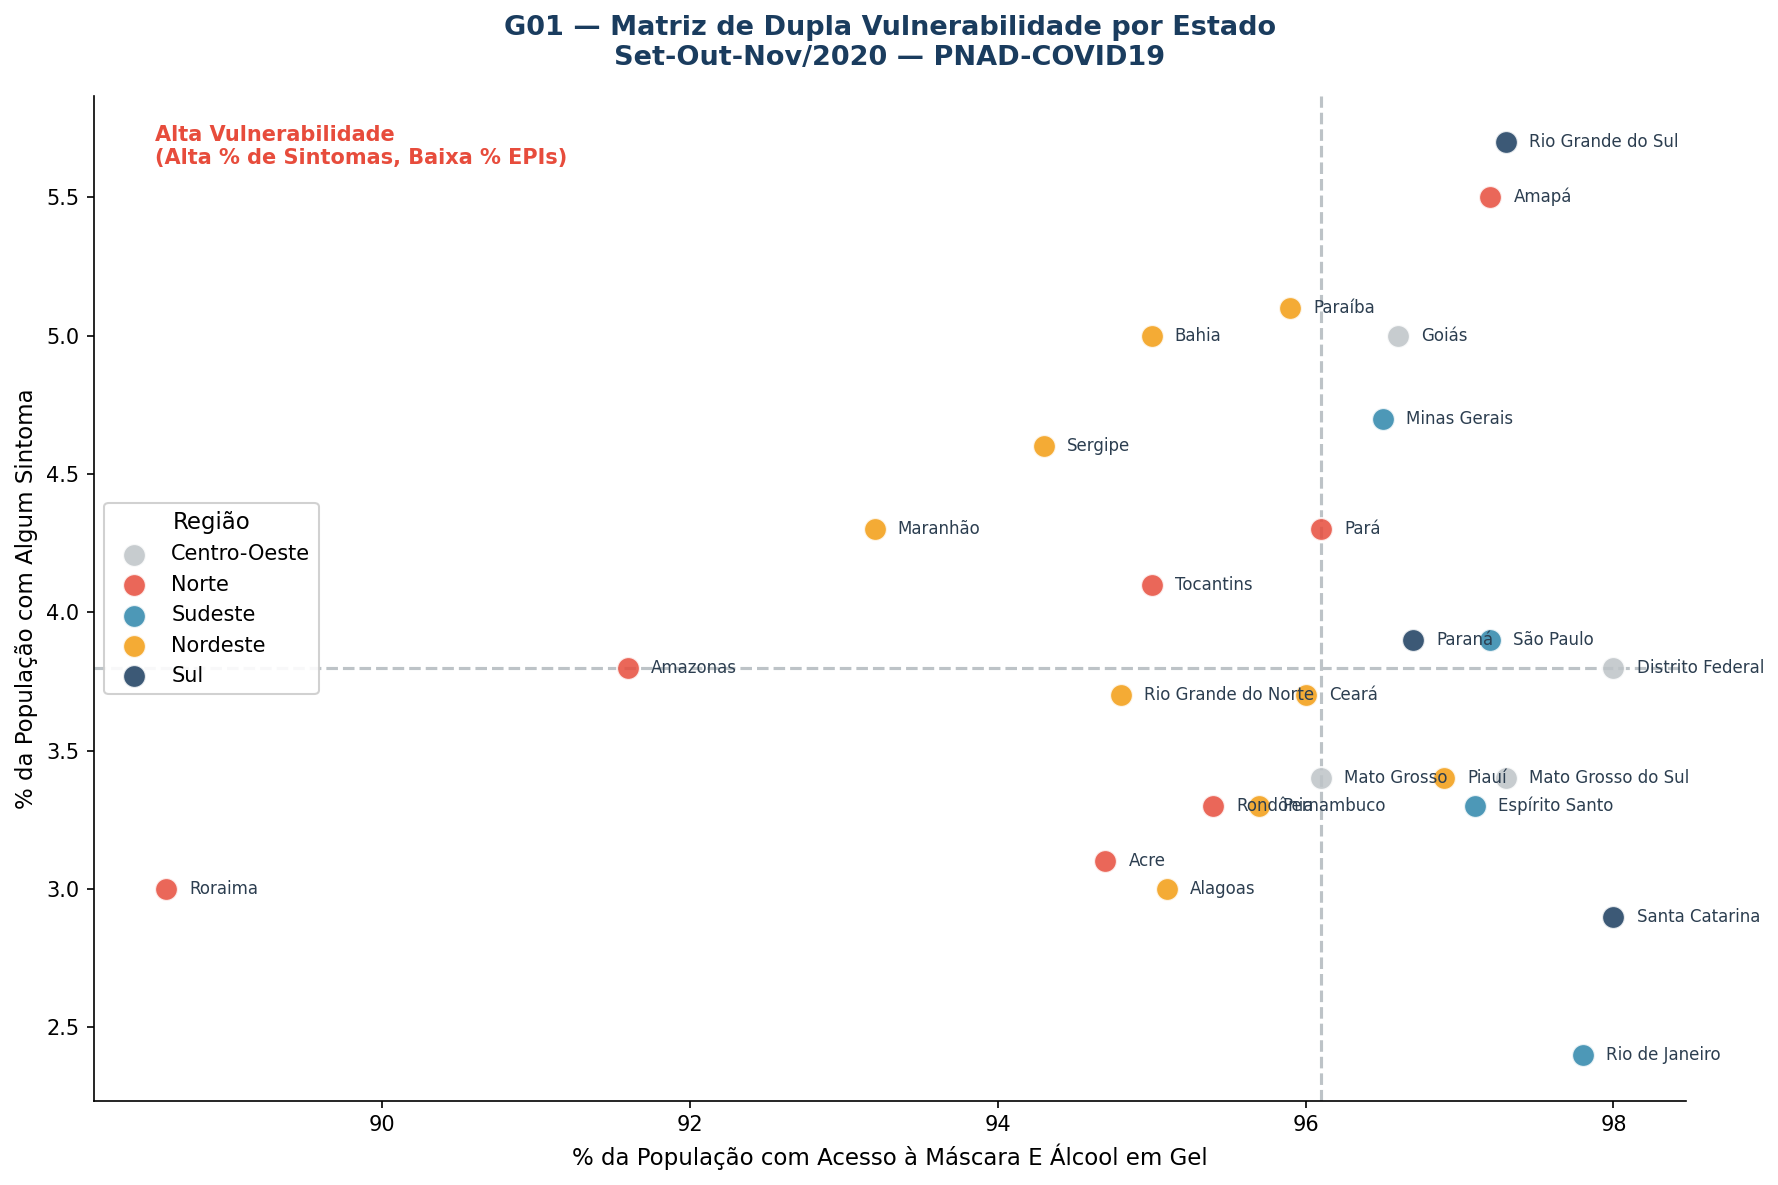

✅ G01 atualizado salvo


In [44]:
# ── G01. Matriz de Vulnerabilidade: Sintomas vs Acesso a EPIs por Estado ──────

df_g01 = q(f"""
    SELECT
        uf,
        CASE
            WHEN uf IN ('Rondônia','Acre','Amazonas','Roraima','Pará','Amapá','Tocantins') THEN 'Norte'
            WHEN uf IN ('Maranhão','Piauí','Ceará','Rio Grande do Norte','Paraíba','Pernambuco','Alagoas','Sergipe','Bahia') THEN 'Nordeste'
            WHEN uf IN ('Minas Gerais','Espírito Santo','Rio de Janeiro','São Paulo') THEN 'Sudeste'
            WHEN uf IN ('Paraná','Santa Catarina','Rio Grande do Sul') THEN 'Sul'
            WHEN uf IN ('Mato Grosso do Sul','Mato Grosso','Goiás','Distrito Federal') THEN 'Centro-Oeste'
        END AS regiao,
        ROUND(100.0 * SUM(CASE
            WHEN sintoma_febre                = 'Sim'
              OR sintoma_tosse                = 'Sim'
              OR sintoma_dor_garganta         = 'Sim'
              OR sintoma_dificuldade_respirar = 'Sim'
              OR sintoma_dor_cabeca           = 'Sim'
              OR sintoma_dor_peito            = 'Sim'
              OR sintoma_nausea               = 'Sim'
              OR sintoma_coriza               = 'Sim'
              OR sintoma_fadiga               = 'Sim'
              OR sintoma_dor_olhos            = 'Sim'
              OR sintoma_perda_olfato_paladar = 'Sim'
              OR sintoma_dor_muscular         = 'Sim'
              OR sintoma_diarreia             = 'Sim'
            THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_sintomas,
        ROUND(100.0 * SUM(CASE 
            WHEN item_alcool_gel = 'Sim' AND item_mascara = 'Sim' 
            THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_epi
    FROM {TABELA}
    WHERE uf IS NOT NULL
    GROUP BY 1, 2
""")

fig, ax = plt.subplots(figsize=(12, 8))

# Mapeamento de cores por região
cores_regiao = {
    'Norte':        PALETA['vermelho'],
    'Nordeste':     PALETA['ambar'],
    'Centro-Oeste': PALETA['cinza_claro'],
    'Sudeste':      PALETA['azul_medio'],
    'Sul':          PALETA['azul_profundo']
}

# Plot dos pontos por região para gerar a legenda corretamente
for regiao in df_g01['regiao'].unique():
    subset = df_g01[df_g01['regiao'] == regiao]
    ax.scatter(subset['pct_epi'], subset['pct_sintomas'], 
               color=cores_regiao[regiao], label=regiao, 
               s=120, alpha=0.85, edgecolor='white', linewidth=1)

# Rótulos com as siglas/nomes dos estados ao lado das bolhas
for i, row in df_g01.iterrows():
    ax.text(row['pct_epi'] + 0.15, row['pct_sintomas'], row['uf'], 
            fontsize=8, color=PALETA['cinza_escuro'], va='center')

# Linhas de quadrante (usando a mediana para dividir bem os estados)
mediana_epi = df_g01['pct_epi'].median()
mediana_sintomas = df_g01['pct_sintomas'].median()

ax.axvline(mediana_epi, color=PALETA['cinza_claro'], linestyle='--', zorder=0)
ax.axhline(mediana_sintomas, color=PALETA['cinza_claro'], linestyle='--', zorder=0)

# Caixa de Anotação do Quadrante Crítico (Superior Esquerdo)
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
ax.text(xmin + (mediana_epi - xmin)*0.05, ymax - (ymax - mediana_sintomas)*0.05, 
        'Alta Vulnerabilidade\n(Alta % de Sintomas, Baixa % EPIs)', 
        fontsize=10, fontweight='bold', color=PALETA['vermelho'], 
        ha='left', va='top', bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

ax.set_xlabel('% da População com Acesso à Máscara E Álcool em Gel', fontsize=11)
ax.set_ylabel('% da População com Algum Sintoma', fontsize=11)
ax.set_title('G01 — Matriz de Dupla Vulnerabilidade por Estado\nSet-Out-Nov/2020 — PNAD-COVID19',
             fontsize=13, fontweight='bold', color=PALETA['azul_profundo'], pad=15)

ax.legend(fontsize=10, loc='center left', framealpha=0.9, title="Região", title_fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G01_sintomas_por_uf.png')
plt.show()
print("✅ G01 atualizado salvo")

  → Executando...
     8 linhas retornadas


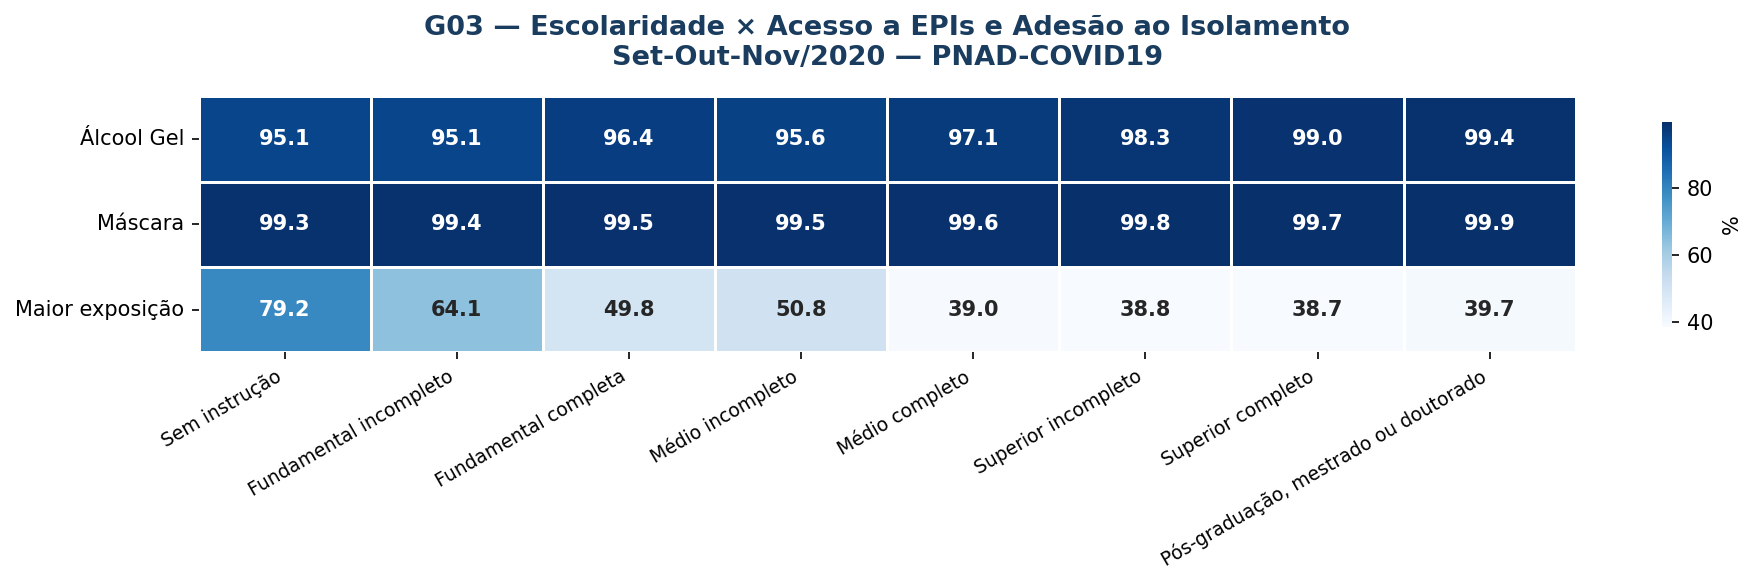

✅ G03 salvo


In [45]:
# ── G03. Heatmap — escolaridade × EPIs e isolamento ──────────────────────────

df_g03 = q(f"""
    SELECT
        escolaridade,
        ROUND(100.0 * SUM(CASE WHEN item_alcool_gel = 'Sim' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_alcool_gel,
        ROUND(100.0 * SUM(CASE WHEN item_mascara   = 'Sim' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_mascara,
        ROUND(100.0 * SUM(CASE WHEN nivel_isolamento IN (
                'Ficou em casa e só saiu em caso de necessidade básica',
                'Ficou rigorosamente em casa') THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN nivel_isolamento IS NOT NULL THEN 1 ELSE 0 END), 0), 1) AS pct_isolamento_rigoroso
    FROM {TABELA}
    WHERE escolaridade IS NOT NULL
    GROUP BY escolaridade
""")

# Ordem lógica de escolaridade
ordem_esc = [
    'Sem instrução',
    'Fundamental incompleto',
    'Fundamental completa', 
    'Médio incompleto',
    'Médio completo',
    'Superior incompleto',
    'Superior completo',
    'Pós-graduação, mestrado ou doutorado',
]

df_g03 = df_g03.set_index('escolaridade').reindex(ordem_esc).reset_index()

# Monta matriz para heatmap
matriz = df_g03.set_index('escolaridade')[['pct_alcool_gel', 'pct_mascara', 'pct_isolamento_rigoroso']].T
matriz.index = ['Álcool Gel', 'Máscara', 'Maior exposição']

fig, ax = plt.subplots(figsize=(13, 4))

sns.heatmap(
    matriz,
    ax=ax,
    cmap='Blues',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '%', 'shrink': 0.8},
    annot_kws={'size': 10, 'weight': 'bold'},
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title('G03 — Escolaridade × Acesso a EPIs e Adesão ao Isolamento\nSet-Out-Nov/2020 — PNAD-COVID19',
             fontsize=13, fontweight='bold', color=PALETA['azul_profundo'], pad=15)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G03_heatmap_escolaridade_epi.png')
plt.show()
print("✅ G03 salvo")

  → Executando...
     18 linhas retornadas


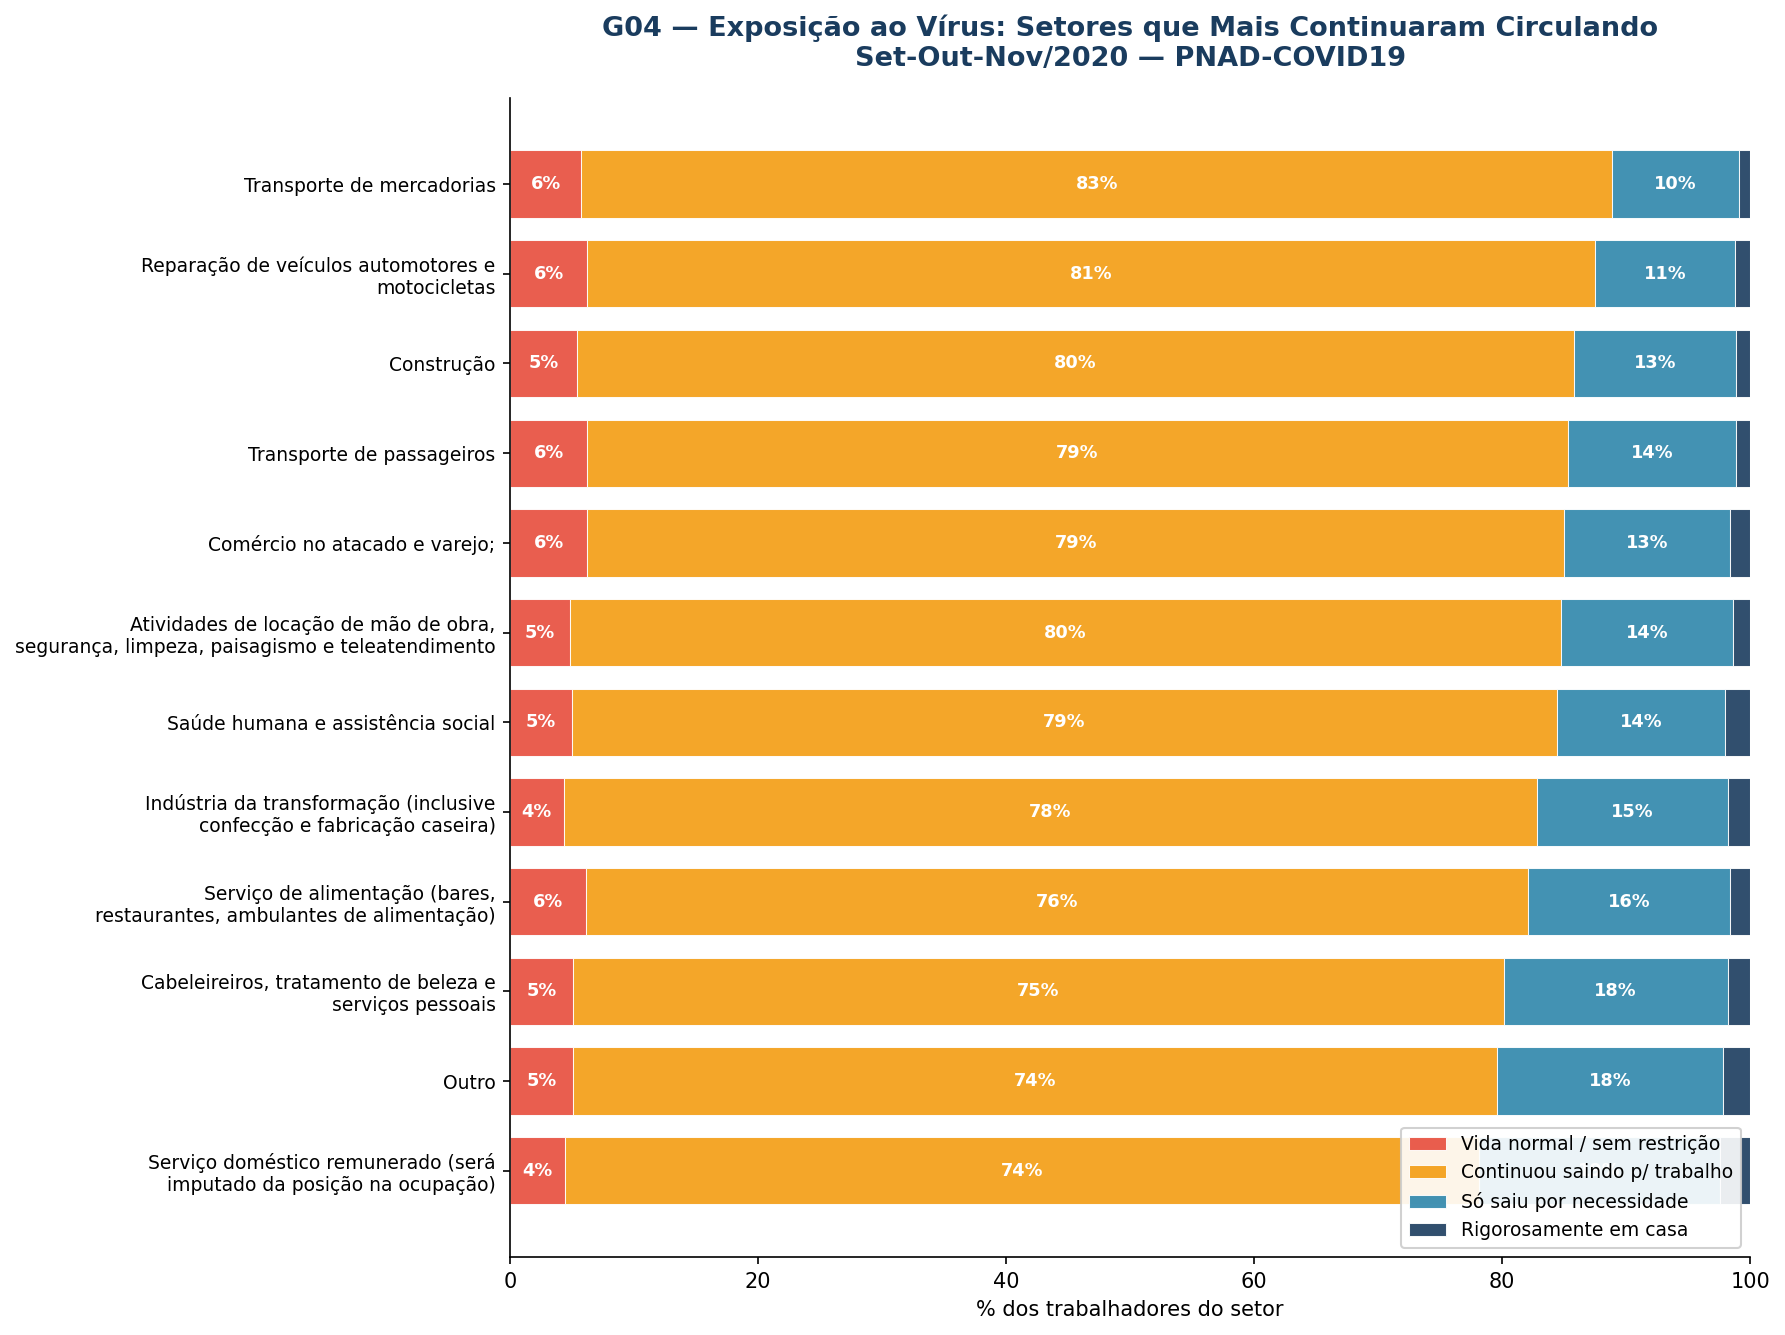

✅ G04 atualizado salvo


In [47]:
# ── G04. Isolamento × setor de atividade (Ordenado por Exposição) ─────────────

df_g04 = q(f"""
    SELECT
        setor_atividade_empresa,
        ROUND(100.0 * SUM(CASE WHEN nivel_isolamento = 'Ficou rigorosamente em casa'
                 THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN nivel_isolamento IS NOT NULL THEN 1 ELSE 0 END), 0), 1) AS pct_rigoroso,
        ROUND(100.0 * SUM(CASE WHEN nivel_isolamento = 'Ficou em casa e só saiu em caso de necessidade básica'
                 THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN nivel_isolamento IS NOT NULL THEN 1 ELSE 0 END), 0), 1) AS pct_necessidade,
        ROUND(100.0 * SUM(CASE WHEN nivel_isolamento = 'Reduziu o contato com as pessoas, mas continuou saindo de casa para trabalho ou atividades não essenciais e/ou recebendo visitas'
         THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN nivel_isolamento IS NOT NULL THEN 1 ELSE 0 END), 0), 1) AS pct_reduziu,
        ROUND(100.0 * SUM(CASE WHEN nivel_isolamento = 'Não fez restrição, levou vida normal como antes da pandemia'
                 THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN nivel_isolamento IS NOT NULL THEN 1 ELSE 0 END), 0), 1) AS pct_normal,
        SUM(CASE WHEN nivel_isolamento IS NOT NULL THEN 1 ELSE 0 END) AS total_respondeu
    FROM {TABELA}
    WHERE setor_atividade_empresa IS NOT NULL
      AND nivel_isolamento IS NOT NULL
    GROUP BY setor_atividade_empresa
    HAVING SUM(CASE WHEN nivel_isolamento IS NOT NULL THEN 1 ELSE 0 END) > 5000
""")

# Garante que soma = 100% (ajuste de arredondamento)
cols = ['pct_rigoroso', 'pct_necessidade', 'pct_reduziu', 'pct_normal']
df_g04[cols] = df_g04[cols].div(df_g04[cols].sum(axis=1), axis=0) * 100

# 👉 A SUA SACADA AQUI: Criar o índice de exposição
df_g04['taxa_exposicao'] = df_g04['pct_normal'] + df_g04['pct_reduziu']

# Ordena os Top 12 setores mais expostos e inverte a ordem para o gráfico (maior no topo)
df_g04 = df_g04.sort_values('taxa_exposicao', ascending=False).head(12)
df_g04 = df_g04.sort_values('taxa_exposicao', ascending=True)

# Nomes curtos para caber no gráfico
df_g04['setor_curto'] = df_g04['setor_atividade_empresa'].str.replace(
    r'(.{30,40})\s', r'\1\n', regex=True, n=1
)

fig, ax = plt.subplots(figsize=(12, 9))

y    = np.arange(len(df_g04))
left = np.zeros(len(df_g04))

camadas = [
    ('pct_normal',      'Vida normal / sem restrição',  PALETA['vermelho']),
    ('pct_reduziu',     'Continuou saindo p/ trabalho', PALETA['ambar']),
    ('pct_necessidade', 'Só saiu por necessidade',      PALETA['azul_medio']),
    ('pct_rigoroso',    'Rigorosamente em casa',        PALETA['azul_profundo']),
]

for col, label, cor in camadas:
    vals = df_g04[col].values
    ax.barh(y, vals, left=left, color=cor, alpha=0.9,
            label=label, height=0.75, edgecolor='white', linewidth=0.5)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v >= 3: # Mantive o seu limite de 3%
            ax.text(l + v/2, i, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    left = left + vals

ax.set_yticks(y)
ax.set_yticklabels(df_g04['setor_curto'], fontsize=9)
ax.set_xlabel('% dos trabalhadores do setor', fontsize=10)
ax.set_xlim(0, 100)

# Título ajustado para refletir a nova lógica
ax.set_title('G04 — Exposição ao Vírus: Setores que Mais Continuaram Circulando\nSet-Out-Nov/2020 — PNAD-COVID19',
             fontsize=13, fontweight='bold', color=PALETA['azul_profundo'], pad=15)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G04_isolamento_setor.png')
plt.show()
print("✅ G04 atualizado salvo")

In [48]:
# Retorna a lista completa de colunas para copiar e colar
print(list(_df.columns))

['uf', 'semana_entrevista', 'mes_referencia', 'idade', 'sexo', 'raca', 'escolaridade', 'sintoma_febre', 'sintoma_tosse', 'sintoma_dor_garganta', 'sintoma_dificuldade_respirar', 'sintoma_dor_cabeca', 'sintoma_dor_peito', 'sintoma_nausea', 'sintoma_coriza', 'sintoma_fadiga', 'sintoma_dor_olhos', 'sintoma_perda_olfato_paladar', 'sintoma_dor_muscular', 'sintoma_diarreia', 'buscou_atendimento', 'remedio_conta_propria', 'atendimento_posto_ubs', 'atendimento_upa_sus', 'atendimento_hospital_sus', 'atendimento_consultorio_privado', 'atendimento_ps_privado', 'atendimento_hospital_privado', 'foi_internado', 'fez_teste_covid', 'resultado_teste_swab', 'resultado_teste_sangue_dedo', 'resultado_teste_sangue_veia', 'nivel_isolamento', 'trabalhou_semana', 'recebeu_remuneracao_afastado', 'setor_atividade_empresa', 'recebeu_auxilio_emergencial', 'recebeu_seguro_desemprego', 'solicitou_emprestimo', 'item_alcool_gel', 'item_mascara']


  → Executando...
     2 linhas retornadas


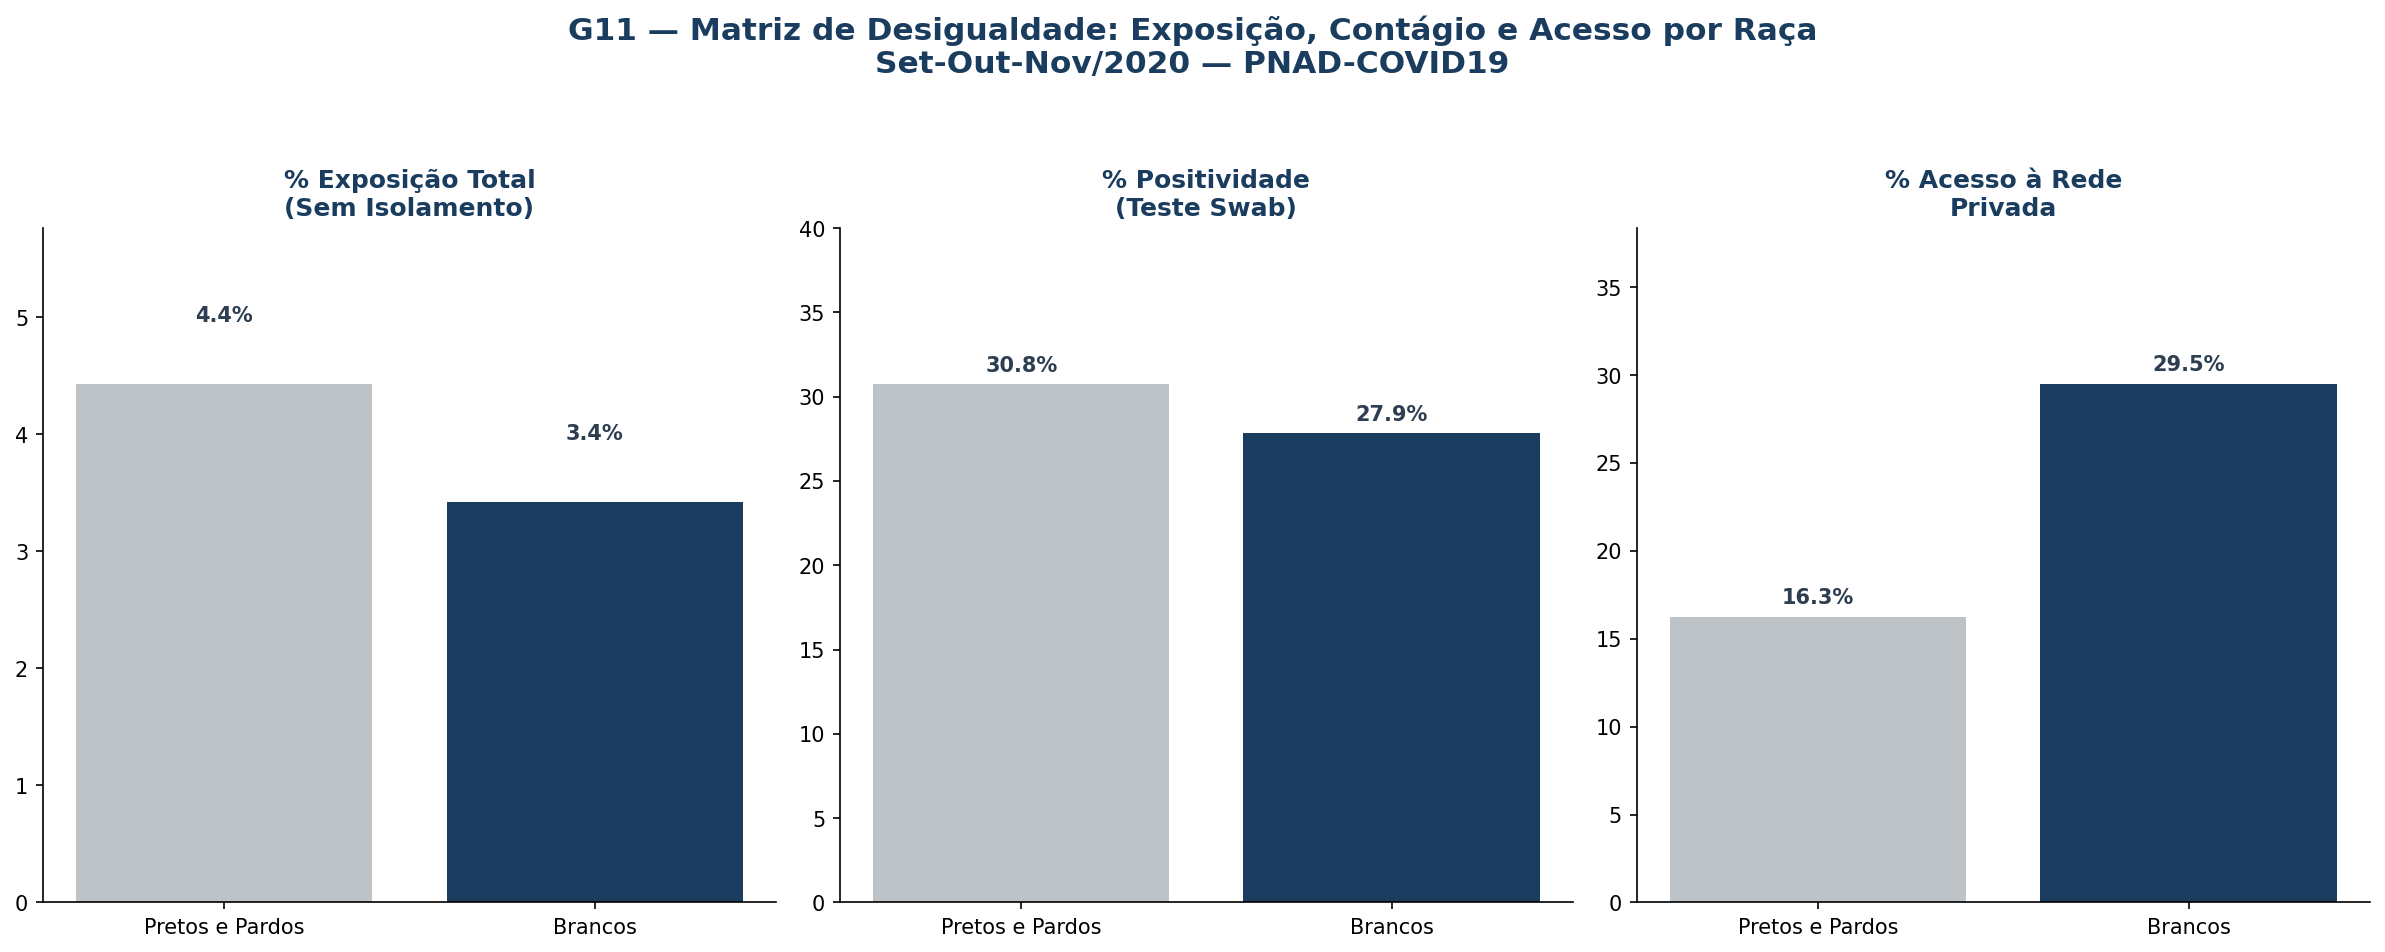

In [49]:
# ── G03. Tripla Vulnerabilidade: Impacto da Raça na Pandemia ──────────────────

df_g03 = q(f"""
    SELECT 
        CASE 
            WHEN raca = 'Preta' OR raca = 'Parda' THEN 'Pretos e Pardos'
            WHEN raca = 'Branca' THEN 'Brancos'
            ELSE 'Outros' 
        END AS grupo_raca,
        -- 1. Exposição (Não fez isolamento)
        AVG(CASE WHEN nivel_isolamento = 'Não fez restrição, levou vida normal como antes da pandemia' 
                 THEN 100.0 ELSE 0.0 END) AS pct_exposicao,
        -- 2. Positividade (Swab Positivo)
        AVG(CASE WHEN resultado_teste_swab = 'Positivo' THEN 100.0 
                 WHEN resultado_teste_swab = 'Negativo' THEN 0.0 END) AS pct_positividade,
        -- 3. Acesso Privado (Proxy para Plano de Saúde/Renda)
        AVG(CASE WHEN buscou_atendimento = 'Sim' AND 
                 (atendimento_consultorio_privado = 'Sim' OR 
                  atendimento_ps_privado = 'Sim' OR 
                  atendimento_hospital_privado = 'Sim') THEN 100.0 
                 WHEN buscou_atendimento = 'Sim' THEN 0.0 END) AS pct_acesso_privado
    FROM {TABELA}
    WHERE raca IN ('Preta', 'Parda', 'Branca')
    GROUP BY 1
""")

# Preparação para o gráfico
df_plot = df_g03[df_g03['grupo_raca'] != 'Outros'].set_index('grupo_raca')
metrics = ['pct_exposicao', 'pct_positividade', 'pct_acesso_privado']
titles = ['% Exposição Total\n(Sem Isolamento)', '% Positividade\n(Teste Swab)', '% Acesso à Rede\nPrivada']
colors = [PALETA['vermelho'], PALETA['vermelho'], PALETA['azul_medio']]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, ax in enumerate(axes):
    metric = metrics[i]
    # Invertendo a ordem para Pretos/Pardos ficarem em cima ou primeiro
    bars = ax.bar(df_plot.index, df_plot[metric], color=[PALETA['cinza_claro'], PALETA['azul_profundo']])
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', color=PALETA['azul_profundo'])
    ax.set_ylim(0, df_plot[metric].max() * 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Rótulos de dados
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', 
                ha='center', va='bottom', fontweight='bold', color=PALETA['cinza_escuro'])

fig.suptitle('G11 — Matriz de Desigualdade: Exposição, Contágio e Acesso por Raça\nSet-Out-Nov/2020 — PNAD-COVID19', 
             fontsize=15, fontweight='bold', color=PALETA['azul_profundo'], y=1.05)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G03_vulnerabilidade_raca.png')
plt.show()

  → Executando...
     8 linhas retornadas
  → Executando...
     8 linhas retornadas


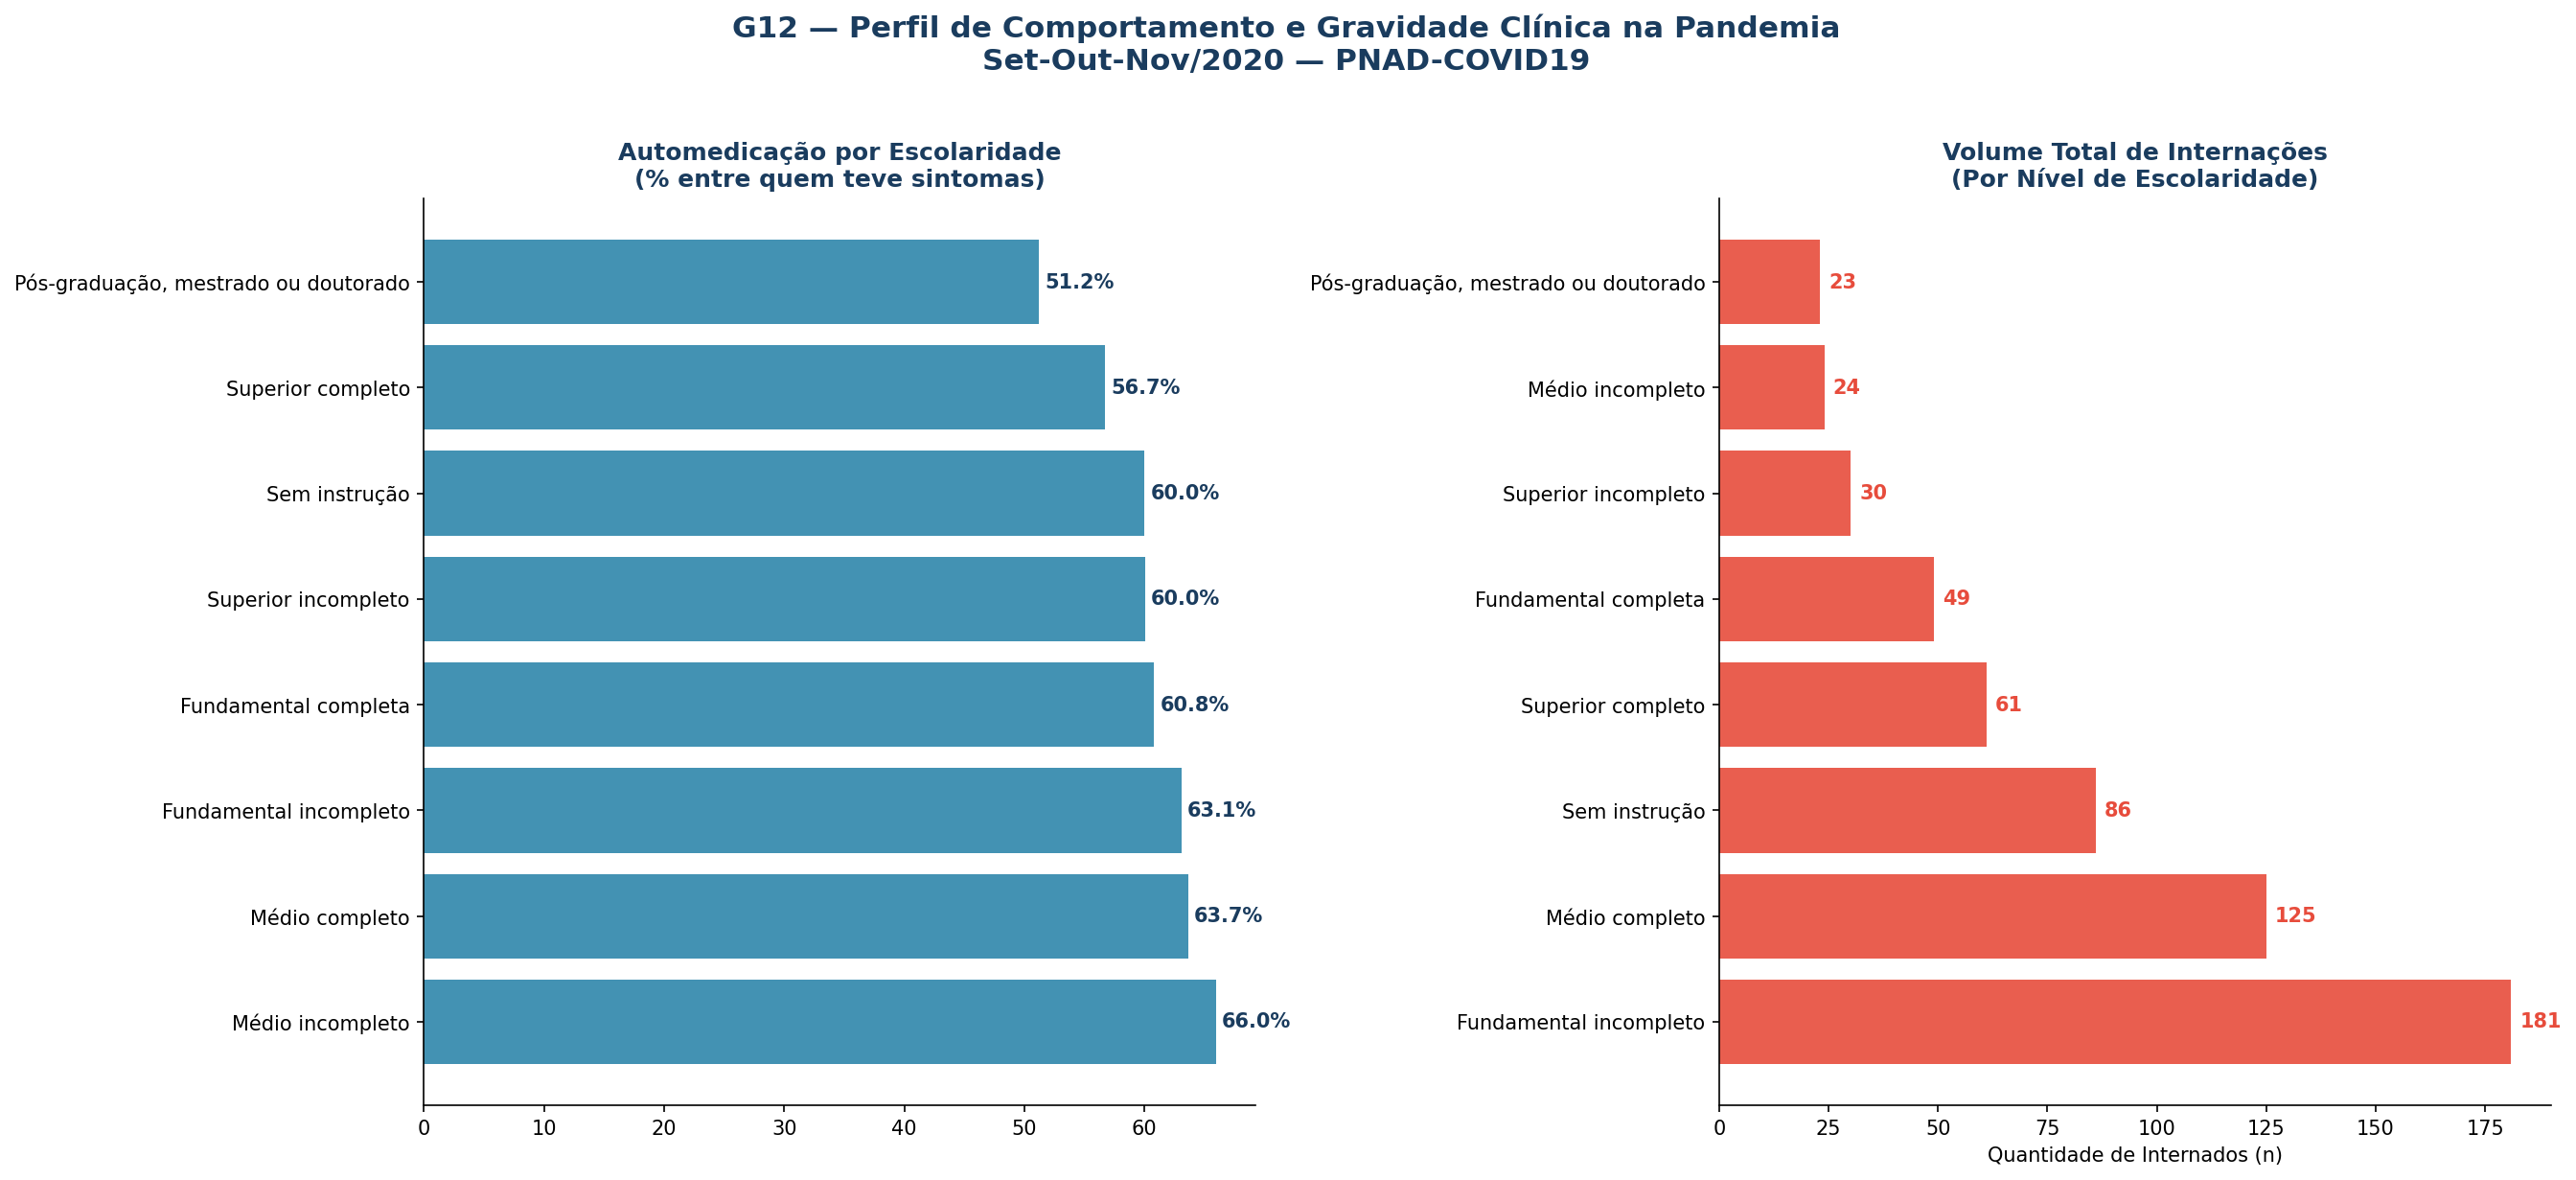

✅ G12 atualizado com a paleta oficial do projeto.


In [50]:
# ── G08. Perfil de Automedicação e Volume de Internação (Paleta Homologada) ──

# 1. Query: Perfil de Automedicação
df_auto = q(f"""
    SELECT 
        escolaridade,
        AVG(CASE WHEN UPPER(TRIM(remedio_conta_propria)) = 'SIM' THEN 100.0 ELSE 0.0 END) AS pct_automedicacao
    FROM {TABELA}
    WHERE remedio_conta_propria IS NOT NULL 
      AND escolaridade IS NOT NULL
    GROUP BY 1
    ORDER BY pct_automedicacao DESC
""")

# 2. Query: Volume de Internação (Independente)
df_internados = q(f"""
    SELECT 
        escolaridade,
        COUNT(*) AS total_internados
    FROM {TABELA}
    WHERE UPPER(TRIM(foi_internado)) = 'SIM'
      AND escolaridade IS NOT NULL
    GROUP BY 1
    ORDER BY total_internados DESC
""")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# ── PAINEL 1: Automedicação (Vertente População) ──────────────────────────────
bars1 = ax1.barh(df_auto['escolaridade'], df_auto['pct_automedicacao'], 
                 color=PALETA['azul_medio'], alpha=0.9)

ax1.set_title('Automedicação por Escolaridade\n(% entre quem teve sintomas)', 
               fontsize=12, fontweight='bold', color=PALETA['azul_profundo'])

for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', va='center', fontweight='bold', color=PALETA['azul_profundo'])

# ── PAINEL 2: Internação (Vertente Clínica) ───────────────────────────────────
if not df_internados.empty:
    # Aplicando o vermelho da vertente clínica conforme solicitado
    bars2 = ax2.barh(df_internados['escolaridade'], df_internados['total_internados'], 
                      color=PALETA['vermelho'], alpha=0.9)
    
    ax2.set_title('Volume Total de Internações\n(Por Nível de Escolaridade)', 
                   fontsize=12, fontweight='bold', color=PALETA['azul_profundo'])
    ax2.set_xlabel('Quantidade de Internados (n)', fontsize=10)

    for bar in bars2:
        width = bar.get_width()
        ax2.text(width + 2, bar.get_y() + bar.get_height()/2, 
                 f'{int(width)}', va='center', fontweight='bold', color=PALETA['vermelho'])
else:
    ax2.text(0.5, 0.5, "Sem dados de internação", ha='center', va='center')

# Estética Geral (Respeitando rcParams)
fig.suptitle('G12 — Perfil de Comportamento e Gravidade Clínica na Pandemia\nSet-Out-Nov/2020 — PNAD-COVID19', 
             fontsize=15, fontweight='bold', color=PALETA['azul_profundo'], y=1.02)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G08_perfil_gravidade_final.png')
plt.show()

print("✅ G12 atualizado com a paleta oficial do projeto.")